# **Phân tích Chương 2: Con người & Chất lượng cuộc sống**

- Load dataset và kiểm tra các thuộc tính

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from IPython.display import display, Markdown
import warnings
from matplotlib import MatplotlibDeprecationWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

pd.set_option('display.max_columns', None)

df = pd.read_parquet('../../data/wdi_cleaned.parquet')

df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9035403 entries, 0 to 9035402
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Country Name    object 
 1   Country Code    object 
 2   Indicator Name  object 
 3   Indicator Code  object 
 4   Year            int64  
 5   Value           float64
 6   Region          object 
 7   Income Group    object 
 8   Topic           object 
dtypes: float64(1), int64(1), object(7)
memory usage: 620.4+ MB


## **Câu hỏi 1: Quốc gia càng giàu thì người dân sống càng thọ, điều này có luôn đúng không? Nhóm nước nào đang tụt lại phía sau?**

### **Bước 1: Chuẩn bị dữ liệu**

#### Lọc 2 chỉ số quan trọng

In [63]:
# Chọn 2 chỉ số quan trọng
life_exp = "Life expectancy at birth, total (years)"
gdp_pc = "GDP per capita (current US$)"

df_sub = df[df['Indicator Name'].isin([life_exp, gdp_pc])]

display(Markdown(f"""
## Dữ liệu được chọn
- Chỉ số 1: **{life_exp}**
- Chỉ số 2: **{gdp_pc}**
- Tổng số dòng sau khi lọc: **{len(df_sub):,}**
"""))


## Dữ liệu được chọn
- Chỉ số 1: **Life expectancy at birth, total (years)**
- Chỉ số 2: **GDP per capita (current US$)**
- Tổng số dòng sau khi lọc: **31,487**


#### Pivot để ghép 2 chỉ số vào cùng 1 dòng

In [64]:
df_pivot = df_sub.pivot_table(
    index=['Country Name', 'Year', 'Income Group'],
    columns='Indicator Name',
    values='Value'
).reset_index()

# Xóa missing
df_pivot = df_pivot.dropna()

display(Markdown(f"""
## Sau khi pivot & clean
- Số dòng còn lại: **{len(df_pivot):,}**
"""))

df_pivot.head()


## Sau khi pivot & clean
- Số dòng còn lại: **11,245**


Indicator Name,Country Name,Year,Income Group,GDP per capita (current US$),"Life expectancy at birth, total (years)"
40,Afghanistan,2000,Low income,174.930991,55.005
41,Afghanistan,2001,Low income,138.706822,55.511
42,Afghanistan,2002,Low income,178.954088,56.225
43,Afghanistan,2003,Low income,198.871116,57.171
44,Afghanistan,2004,Low income,221.763654,57.810


### **Bước 2: Phân tích & Trực quan hóa**

#### **Biểu đồ 1: Scatter plot (GDP vs Life Expectancy)**


**Mục tiêu**

Xem mối quan hệ: giàu hơn -> sống lâu hơn?

**Lý do chọn:**

**Việc sử dụng scatter plot cho phép:**
- Quan sát xu hướng tổng thể (tăng, giảm hay không có mối liên hệ)
- Phát hiện các cụm dữ liệu theo nhóm thu nhập thông qua màu sắc (hue)
- Nhận diện các điểm ngoại lệ (outliers)

---

**Trục GDP được chuyển sang thang log nhằm:**
- Giảm độ lệch do phân phối không đồng đều (skewed distribution)
- Giúp dữ liệu trải đều hơn, tránh việc các quốc gia có GDP thấp bị dồn vào một phía

---

**Cách biểu diễn này giúp đảm bảo:**
- Không làm méo dữ liệu
- Dễ quan sát xu hướng thực tế
- Tránh gây hiểu nhầm do phân phối lệch

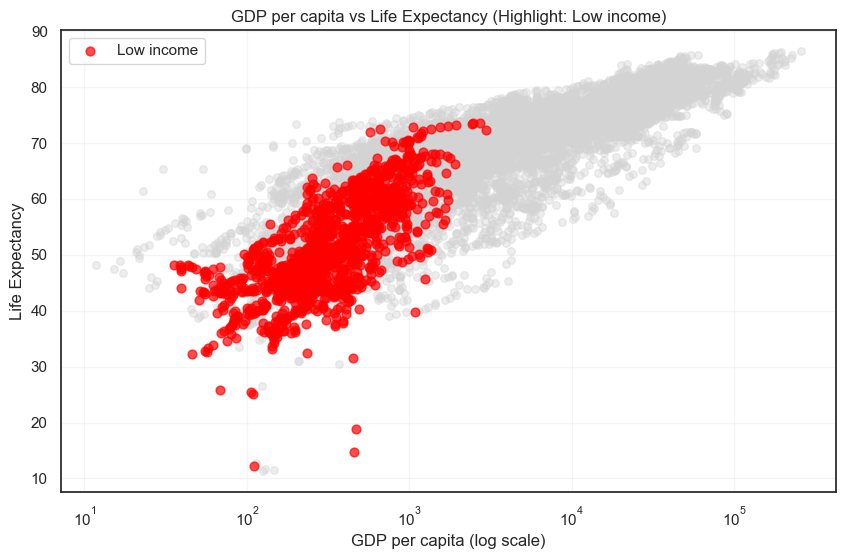

In [65]:
plt.figure(figsize=(10,6))

# Các nhóm khác → màu xám
df_other = df_pivot[df_pivot['Income Group'] != 'Low income']
plt.scatter(
    df_other[gdp_pc],
    df_other[life_exp],
    color='lightgray',
    alpha=0.4,
    s=30
)

# Nhóm cần highlight
df_focus = df_pivot[df_pivot['Income Group'] == 'Low income']
plt.scatter(
    df_focus[gdp_pc],
    df_focus[life_exp],
    color='red',
    alpha=0.7,
    s=40,
    label='Low income'
)

plt.xscale('log')
plt.grid(alpha=0.2)

plt.title("GDP per capita vs Life Expectancy (Highlight: Low income)")
plt.xlabel("GDP per capita (log scale)")
plt.ylabel("Life Expectancy")

plt.legend()
plt.show()

**Nhận xét và insight từ biểu đồ**

**Mối quan hệ giữa Thu nhập và Sức khỏe**
- Tồn tại **mối quan hệ thuận chiều (dương)** rõ rệt: GDP bình quân đầu người càng cao, tuổi thọ trung bình càng tăng.
- Các quốc gia có **mức thu nhập cao hơn** thường đi kèm với nền tảng sức khỏe và **tuổi thọ vượt trội**.

---

**Hiệu ứng bão hòa (Sự phi tuyến tính)**
- Khi GDP đạt đến một ngưỡng nhất định, tốc độ gia tăng tuổi thọ **chậm lại đáng kể**.

---

**Phân tầng giữa các nhóm thu nhập**
- **Nhóm thu nhập thấp**: Tập trung ở vùng GDP thấp và tuổi thọ thấp, đồng thời có **độ phân tán lớn**, phản ánh mức độ **bất ổn cao** và chênh lệch nội bộ đáng kể.
- **Nhóm thu nhập cao**: Tập trung ở vùng tuổi thọ cao với **phân bố ổn định hơn**, cho thấy mức độ phát triển đồng đều và bền vững.

---

**Insight chính**

> Sự tụt lại rõ rệt của nhóm thu nhập thấp cho thấy khoảng cách khổng lồ về cả mức sống lẫn quyền lợi chăm sóc sức khỏe dân số.

#### **Biểu đồ 2: Boxplot theo Income Group**

**Mục tiêu**:

- So sánh tuổi thọ giữa các nhóm thu nhập

---


**Lý do chọn:** 
- Thể hiện được giá trị trung vị (median)
- Cho thấy độ phân tán dữ liệu (IQR)
- Phát hiện các giá trị ngoại lệ (outliers)

So với các biểu đồ khác như bar chart (chỉ thể hiện giá trị trung bình), boxplot cung cấp cái nhìn đầy đủ hơn về phân phối dữ liệu trong từng nhóm.

---

**Việc sử dụng boxplot giúp:**
- So sánh trực quan giữa các nhóm thu nhập
- Tránh hiểu nhầm do chỉ nhìn vào giá trị trung bình
- Phản ánh chính xác sự khác biệt và chồng lấn giữa các nhóm

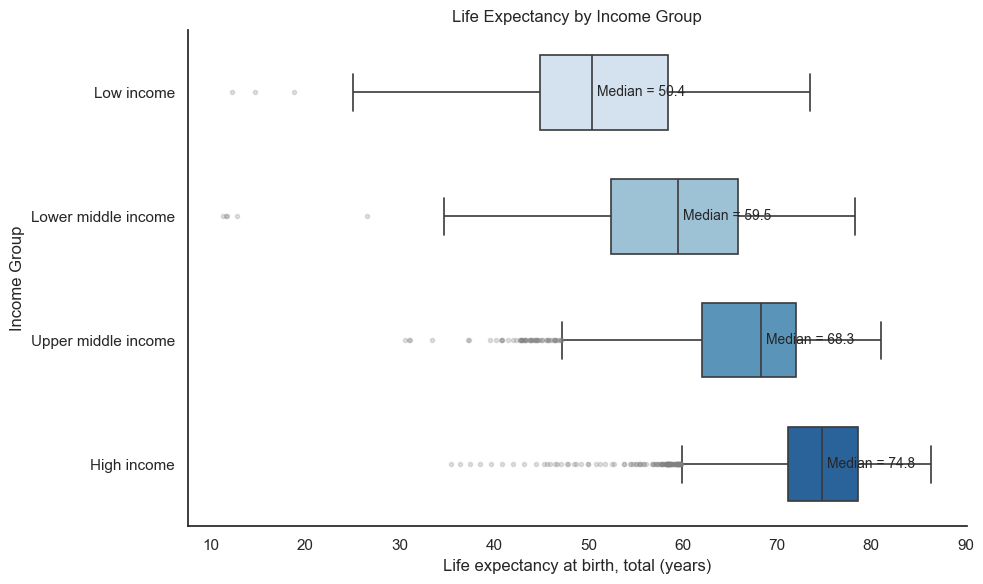

In [66]:
order_income = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']

df_box = df_pivot[df_pivot['Income Group'].isin(order_income)].copy()
df_box['Income Group'] = pd.Categorical(
    df_box['Income Group'],
    categories=order_income,
    ordered=True
)

median_df = (
    df_box.groupby('Income Group', observed=False)[life_exp]
    .median()
    .reindex(order_income)
    .reset_index()
)
median_df.columns = ['Income Group', 'Median']

palette = sns.color_palette("Blues", n_colors=len(order_income))

flierprops = dict(
    marker='o',
    markersize=3,
    markerfacecolor='gray',
    markeredgecolor='gray',
    alpha=0.25
)

plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    data=df_box,
    y='Income Group',
    x=life_exp,
    order=order_income,
    palette=palette,
    showfliers=True,
    flierprops=flierprops,
    width=0.6,
    linewidth=1.2
)

ax.grid(False)
sns.despine(left=False, bottom=False)

for i, row in median_df.iterrows():
    ax.text(
        row['Median'] + 0.5,
        i,
        f"Median = {row['Median']:.1f}",
        va='center',
        ha='left',
        fontsize=10
    )

ax.set_title("Life Expectancy by Income Group")
ax.set_xlabel("Life expectancy at birth, total (years)")
ax.set_ylabel("Income Group")

plt.tight_layout()
plt.show()

**Nhận xét và insight từ biểu đồ Boxplot**

**Xu hướng tăng trưởng theo nhóm thu nhập**
- Tuổi thọ trung bình có **xu hướng tăng tiến** rõ rệt khi đi từ nhóm thu nhập Thấp đến Cao.
- Việc sắp xếp theo trình tự kinh tế giúp làm nổi bật mối liên hệ giữa **tăng trưởng tài chính** và **cải thiện sinh kế**.

---

**Phân tích chi tiết từng phân khúc**
- **Nhóm thu nhập thấp** có tuổi thọ trung vị thấp nhất và độ phân tán lớn, cho thấy **sự chênh lệch nghiêm trọng về điều kiện y tế ngay trong nội bộ** các quốc gia nghèo."
- **Nhóm thu nhập trung bình**: Đóng vai trò là **giai đoạn chuyển tiếp**, cho thấy sự cải thiện rõ rệt về ngưỡng tuổi thọ tối thiểu.
- **Nhóm thu nhập cao**: Có trung vị cao nhất và dữ liệu **tập trung hẹp ở vùng giá trị cao**, minh chứng cho sự ổn định về chất lượng sống và hệ thống y tế xã hội.

---

**Các trường hợp đặc biệt (Outliers & Overlap)**
- **Sự chồng lấn giữa các hộp dữ liệu (overlap)** cho thấy vẫn tồn tại những quốc gia thu nhập trung bình nhưng có tuổi thọ tiệm cận nhóm thu nhập cao, và ngược lại.
- Tồn tại các quốc gia **"vượt mức"**: Thu nhập trung bình nhưng tuổi thọ tương đương nhóm cao.
- Tồn tại các quốc gia **"dưới kỳ vọng"**: Thu nhập cao nhưng tuổi thọ không tương xứng với tiềm lực kinh tế.

---

**Insight chính**

> Biểu đồ xác nhận quy luật: Kinh tế quốc gia càng mạnh, tuổi thọ dân cư càng cao. Tuy nhiên, sự chồng lấn dữ liệu là minh chứng cho thấy các yếu tố phi kinh tế (văn hóa, chế độ dinh dưỡng, chính sách công) vẫn đóng vai trò xoay chuyển cục diện sức khỏe quốc gia.

#### **Biểu đồ 3: Line Chart theo thời gian**

**Mục tiêu:**
- Xem nhóm nào đang bị tụt lại phía sau

---

**Lý do chọn:**

Biểu đồ đường (line chart) được sử dụng để phân tích xu hướng thay đổi tuổi thọ theo thời gian giữa các nhóm thu nhập. Đây là dạng dữ liệu chuỗi thời gian (time-series).

**Line chart phù hợp vì:**
- Thể hiện rõ xu hướng tăng/giảm theo thời gian
- Cho phép so sánh nhiều nhóm cùng lúc thông qua các đường riêng biệt
- Giúp quan sát khoảng cách giữa các nhóm qua từng năm

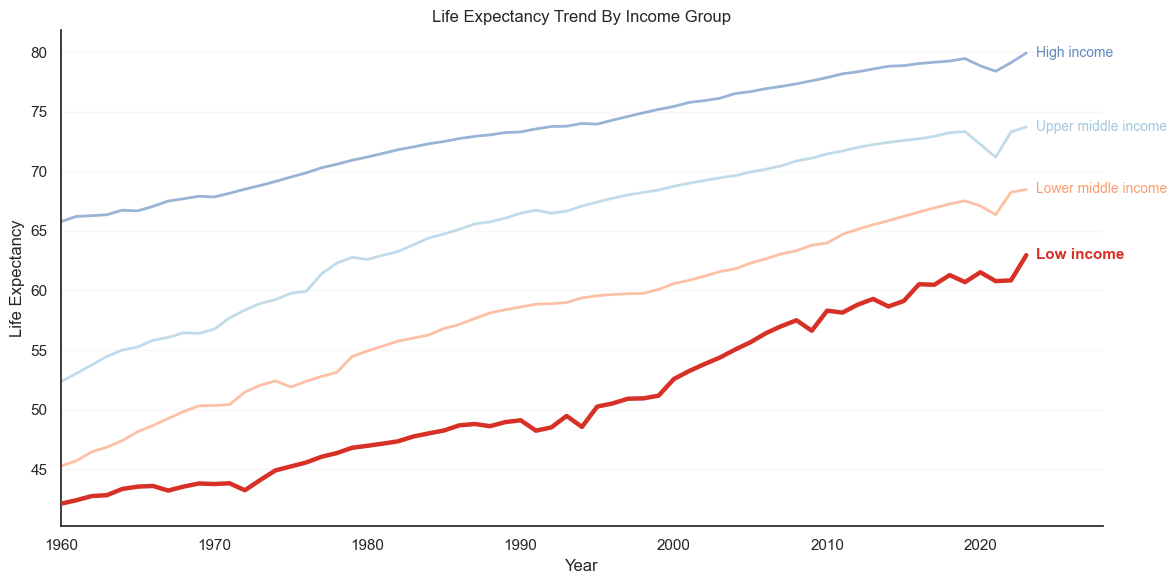

In [67]:
order_income = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']

df_trend = (
    df_pivot[df_pivot['Income Group'].isin(order_income)]
    .groupby(['Year', 'Income Group'], observed=False)[life_exp]
    .mean()
    .reset_index()
)

pivot_trend = (
    df_trend.pivot(index='Year', columns='Income Group', values=life_exp)
    .reindex(columns=order_income)
)

plt.figure(figsize=(12, 6))
ax = plt.gca()

# Dùng nhiều màu khác nhau nhưng vẫn có thứ tự hợp lý theo mức thu nhập
color_map = {
    'Low income': '#d73027',           # đỏ để nhấn mạnh nhóm tụt lại
    'Lower middle income': '#fc8d59',  # cam
    'Upper middle income': '#91bfdb',  # xanh nhạt
    'High income': '#4575b4'           # xanh đậm
}

focus_group = 'Low income'

for group in order_income:
    lw = 3.2 if group == focus_group else 2.0
    alpha = 1.0 if group == focus_group else 0.55
    z = 3 if group == focus_group else 2

    ax.plot(
        pivot_trend.index,
        pivot_trend[group],
        color=color_map[group],
        linewidth=lw,
        alpha=alpha,
        zorder=z
    )

# Gắn nhãn trực tiếp ở cuối mỗi đường
for group in order_income:
    x_last = pivot_trend.index[-1]
    y_last = pivot_trend[group].iloc[-1]

    ax.text(
        x_last + 0.6,
        y_last,
        group,
        color=color_map[group],
        fontsize=11 if group == focus_group else 10,
        va='center',
        ha='left',
        fontweight='bold' if group == focus_group else 'normal',
        alpha=1.0 if group == focus_group else 0.85
    )

# Tinh giản bố cục
ax.grid(axis='y', alpha=0.15)
ax.grid(axis='x', visible=False)
sns.despine()

ax.set_title("Life Expectancy Trend By Income Group")
ax.set_xlabel("Year")
ax.set_ylabel("Life Expectancy")
ax.set_xlim(pivot_trend.index.min(), pivot_trend.index.max() + 5)

plt.tight_layout()
plt.show()

**Nhận xét và insight từ biểu đồ xu hướng**

**Sự cải thiện toàn cầu theo thời gian**
- Tuổi thọ trung bình có **xu hướng tăng trưởng dương** ở tất cả các nhóm thu nhập trong suốt giai đoạn quan sát.
- Phản ánh thành tựu chung của nhân loại về **y tế dự phòng, dinh dưỡng** và cải thiện điều kiện sống cơ bản trên quy mô toàn cầu.

---

**Sự phân hóa và khoảng cách duy trì**
- **Nhóm thu nhập cao**: Luôn xác lập và duy trì **vị thế dẫn đầu** với mức tuổi thọ cao nhất tuyệt đối.
- **Nhóm thu nhập thấp**: Mặc dù có sự đi lên, nhưng luôn nằm ở đáy biểu đồ với **khoảng cách (gap) đáng kể** so với các nhóm còn lại.
- **Đặc điểm đường biểu diễn**: Đường đồ thị của nhóm thu nhập thấp cho thấy sự cải thiện nhưng chưa tạo được sự bứt phá để thu hẹp khoảng cách với các nhóm giàu có hơn.

---

**Insight chính**

> Dù "con tàu" sức khỏe toàn cầu đang đi lên, nhưng các quốc gia thu nhập thấp vẫn đang ở **toa cuối và chưa có dấu hiệu rút ngắn khoảng cách** với toa đầu. Điều này cho thấy sự bất bình đẳng về cấu trúc kinh tế vẫn là rào cản lớn nhất đối với công bằng sức khỏe quốc tế.

#### **Biểu đồ 4: Histogram phân phối tuổi thọ**

**Mục tiêu:**

- Hiểu phân bố tổng thể

**Lý do chọn:**

Biểu đồ histogram được sử dụng để phân tích phân phối của biến tuổi thọ trên toàn bộ tập dữ liệu. Đây là dạng phân tích một biến số (univariate numerical).

**Histogram phù hợp vì:**
- Cho thấy cách dữ liệu được phân bố theo các khoảng giá trị
- Giúp nhận diện dạng phân phối (lệch trái, lệch phải, chuẩn, ...)
- Phát hiện các vùng tập trung dữ liệu

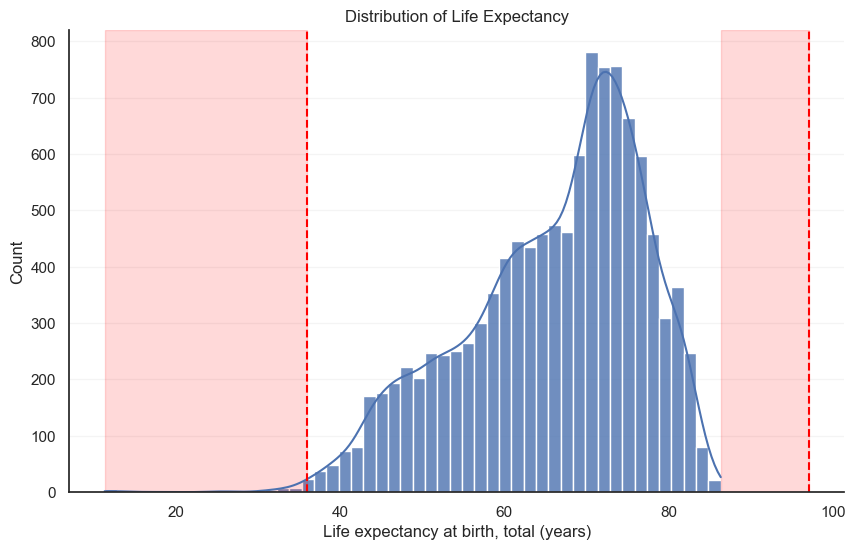

In [68]:
# Tính IQR để xác định outliers
Q1 = df_pivot[life_exp].quantile(0.25)
Q3 = df_pivot[life_exp].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plt.figure(figsize=(10,6))

# Histogram chính
sns.histplot(
    df_pivot[life_exp],
    bins=50,
    kde=True,
    color='#4C72B0',   # xanh dịu hơn
    edgecolor='white',
    alpha=0.8
)

# Highlight vùng outliers (bên trái)
plt.axvspan(
    df_pivot[life_exp].min(),
    lower_bound,
    color='red',
    alpha=0.15
)

# Highlight vùng outliers (bên phải)
plt.axvspan(
    upper_bound,
    df_pivot[life_exp].max(),
    color='red',
    alpha=0.15
)

# Vẽ đường giới hạn
plt.axvline(lower_bound, color='red', linestyle='--', linewidth=1.5)
plt.axvline(upper_bound, color='red', linestyle='--', linewidth=1.5)

# Nhãn
plt.title("Distribution of Life Expectancy")
plt.xlabel("Life expectancy at birth, total (years)")
plt.ylabel("Count")

plt.grid(axis='y', alpha=0.2)
sns.despine()

plt.show()

**Nhận xét và insight từ biểu đồ Histogram**

**Đặc điểm phân phối tổng thể**
- Phân phối dữ liệu có xu hướng **lệch trái (left-skewed)**: Phần lớn các quốc gia tập trung ở mức tuổi thọ trung bình và cao.
- **Mật độ tập trung**: Đa số các quan sát hội tụ trong khoảng `60–75 năm`, phản ánh mức tuổi thọ phổ biến trên bình diện quốc tế.

---

**Nhận diện các giá trị ngoại lai (Outliers)**
- Các vùng tô màu đỏ đánh dấu những quốc gia có chỉ số **nằm ngoài phạm vi thông thường**, được xác định chính xác bằng phương pháp `IQR`.
- Việc chỉ thị trực tiếp giúp người xem nhận diện ngay lập tức các **"điểm trũng" y tế** mà không cần qua các bước suy luận phức tạp.

---

**Nguyên nhân của sự bất thường**
- Các giá trị ngoại lai ở mức thấp thường là hệ quả của các điều kiện đặc biệt khắc nghiệt:
    * **Bất ổn địa chính trị**: Xung đột vũ trang kéo dài.
    * **Khủng hoảng y tế**: Dịch bệnh nghiêm trọng hoặc hệ thống chăm sóc sức khỏe đổ vỡ.
    * **Điều kiện sống**: Thiếu hụt dinh dưỡng và nước sạch trầm trọng.

---

**Insight chính**

> Biểu đồ Histogram khẳng định rằng mặc dù tuổi thọ cao là xu thế chung, nhưng vẫn tồn tại những **"vùng tối" y tế** bị tách rời khỏi phân phối chính. Các quốc gia ngoại lai này chính là những đối tượng cần sự can thiệp và hỗ trợ nhân đạo khẩn cấp nhất để đưa mức sống về lại quỹ đạo chung của thế giới.

## **Bước 3: Kết luận chung**

**Mối liên hệ giữa Kinh tế và Sức khỏe**
- Tồn tại **mối quan hệ thuận chiều** rõ rệt: Thu nhập quốc gia càng cao, tuổi thọ trung bình càng lớn. 
- Tuy nhiên, đây là mối quan hệ **phi tuyến tính**. Khi đạt đến một ngưỡng thu nhập nhất định, tốc độ tăng tuổi thọ sẽ chậm lại (hiệu ứng bão hòa), nhường chỗ cho vai trò của các yếu tố phi kinh tế như **môi trường sống, chính sách xã hội và chất lượng y tế chuyên sâu**.

---

**Sự phân hóa giữa các nhóm thu nhập**
- **Nhóm thu nhập cao**: Duy trì vị thế dẫn đầu với mức tuổi thọ cao nhất và sự phân bố dữ liệu ổn định, đồng đều.
- **Nhóm thu nhập thấp**: Luôn là nhóm **tụt lại phía sau** với tuổi thọ trung vị thấp nhất và độ phân tán lớn, phản ánh tình trạng bất bình đẳng và thiếu ổn định nghiêm trọng.
- **Nhóm thu nhập trung bình**: Đóng vai trò vùng chuyển tiếp nhưng có sự chồng lấn mạnh mẽ, minh chứng rằng thu nhập không phải là biến số duy nhất quyết định sức khỏe dân số.

---

**Xu hướng phát triển và Khoảng cách toàn cầu**
- Mặc dù tuổi thọ đã **tăng trưởng dương ở tất cả các nhóm** kể từ năm 1960, khoảng cách (gap) giữa nhóm giàu nhất và nghèo nhất vẫn chưa được thu hẹp đáng kể.
- Phần lớn thế giới tập trung ở mức tuổi thọ trung bình - cao, nhưng sự tồn tại của các **giá trị ngoại lai (outliers)** ở vùng thấp cảnh báo về những khu vực vẫn đang trong tình trạng khủng hoảng y tế đặc biệt khó khăn.

---

**Insight chính**

> Thu nhập cao là bệ phóng quan trọng nhưng **không phải là điều kiện đủ** để tối ưu hóa tuổi thọ. Khi thế giới ngày càng phát triển, sự thịnh vượng bền vững không chỉ nằm ở tăng trưởng GDP mà còn ở khả năng thu hẹp khoảng cách bất bình đẳng và nâng cao chất lượng sống cho các nhóm yếu thế.

## **Câu hỏi 2: Tốc độ đô thị hóa (người dân rời nông thôn lên thành thị) đang diễn ra nhanh nhất ở những khu vực nào trên thế giới?**

### **Bước 1: Lọc dữ liệu đô thị hóa**

In [69]:
# Chọn chỉ số phù hợp cho phân tích đô thị hóa
indicator_code = "SP.URB.TOTL.IN.ZS"   # Urban population (% of total population)

urban_df = df[df["Indicator Code"] == indicator_code].copy()
urban_df = urban_df.dropna(subset=["Value"])

display(Markdown("### Dữ liệu sau khi lọc chỉ số đô thị hóa"))
display(urban_df.head())

### Dữ liệu sau khi lọc chỉ số đô thị hóa

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value,Region,Income Group,Topic
122,Africa Eastern and Southern,AFE,Urban population (% of total population),SP.URB.TOTL.IN.ZS,1960,14.640371,None,None,Environment: Density & urbanization
244,Africa Western and Central,AFW,Urban population (% of total population),SP.URB.TOTL.IN.ZS,1960,13.946480,None,None,Environment: Density & urbanization
366,Arab World,ARB,Urban population (% of total population),SP.URB.TOTL.IN.ZS,1960,30.946984,None,None,Environment: Density & urbanization
480,Caribbean small states,CSS,Urban population (% of total population),SP.URB.TOTL.IN.ZS,1960,32.234920,None,None,Environment: Density & urbanization
589,Central Europe and the Baltics,CEB,Urban population (% of total population),SP.URB.TOTL.IN.ZS,1960,44.435400,None,None,Environment: Density & urbanization


### **Bước 2: Phân tích & Trực quan hóa**

#### **Biểu đồ 1: Line Chart - Xu hướng đô thị hóa theo thời gian**

**Mục tiêu:**  
Thể hiện xu hướng đô thị hóa theo thời gian của các khu vực trên thế giới từ năm 1960 đến 2024, qua đó so sánh tốc độ tăng trưởng và mức độ hội tụ giữa các khu vực.

**Lý do chọn:**  
- Biểu đồ đường phù hợp để thể hiện xu hướng dài hạn theo thời gian  
- Cho phép so sánh trực tiếp nhiều khu vực trên cùng một trục thời gian  
- Dễ nhận diện sự tăng trưởng, chững lại hoặc bứt phá của từng khu vực  
- Giúp quan sát khoảng cách giữa các khu vực có thu hẹp hay không  

## Line Chart: Urbanization Trends by Region

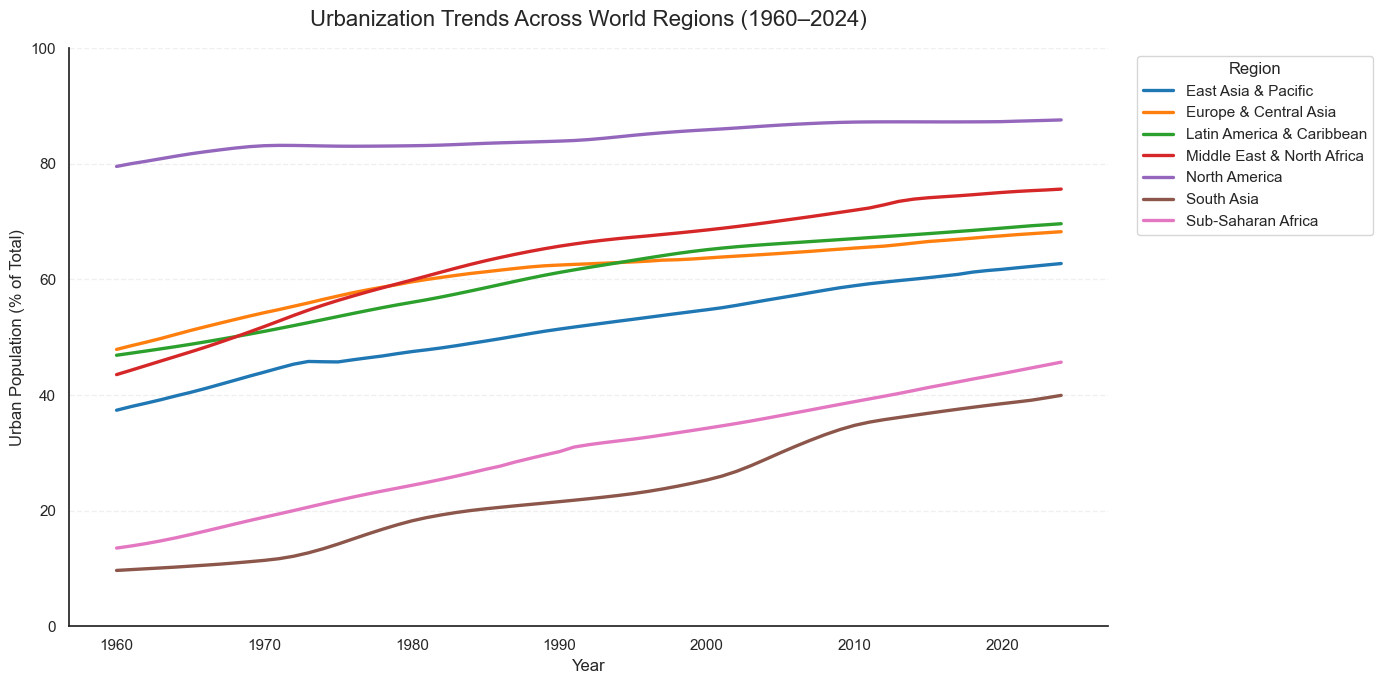

In [70]:
region_year = urban_df.groupby(["Region", "Year"])["Value"].mean().reset_index()

# Lấy danh sách các vùng để xác định thứ tự vẽ và màu sắc
region_order = sorted(region_year["Region"].unique())

display(Markdown("## Line Chart: Urbanization Trends by Region"))

fig, ax = plt.subplots(figsize=(14, 7))

cmap = plt.get_cmap("tab10")
color_map = {region: cmap(i % 10) for i, region in enumerate(region_order)}

for region in region_order:
    temp = region_year[region_year["Region"] == region].sort_values("Year")
    ax.plot(
        temp["Year"],
        temp["Value"],
        linewidth=2.4,
        label=region,
        color=color_map[region]
    )

ax.set_title("Urbanization Trends Across World Regions (1960–2024)", fontsize=16, pad=16)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Urban Population (% of Total)", fontsize=12)
ax.set_ylim(0, 100)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Nhận xét và insight từ biểu đồ xu hướng đô thị hóa**

**Xu thế tăng trưởng toàn cầu**
- **Sự gia tăng đồng nhất**: Tất cả các khu vực trên thế giới đều ghi nhận xu hướng đô thị hóa tăng liên tục trong suốt hơn 6 thập kỷ (1960–2024).
- Phản ánh quá trình chuyển dịch cơ cấu kinh tế mạnh mẽ từ nông nghiệp sang công nghiệp và dịch vụ trên phạm vi toàn cầu.

---

**Sự phân hóa giữa các khu vực**
- **Nhóm dẫn đầu (North America)**: Luôn duy trì mức đô thị hóa cao nhất (tiệm cận 90%). Tốc độ tăng trưởng tại đây chậm và ổn định, cho thấy một xã hội đã đạt đến trạng thái đô thị hóa bão hòa.
- **Nhóm bứt phá (East Asia & Pacific & Middle East)**: Cho thấy sự tăng trưởng dốc và mạnh mẽ nhất. Đặc biệt, East Asia & Pacific đã thu hẹp đáng kể khoảng cách với các khu vực phát triển trong thời gian ngắn.
- **Nhóm thấp (South Asia & Sub-Saharan Africa)**: Mặc dù có sự cải thiện, đây vẫn là hai khu vực có tỷ lệ dân cư đô thị thấp nhất (dưới 50%), phản ánh nền kinh tế vẫn còn phụ thuộc nhiều vào nông thôn.

---

**Insight chính**

> Đô thị hóa là một tiến trình không thể đảo ngược, nhưng tốc độ và mức độ lại phản ánh sự khác biệt về chiến lược phát triển kinh tế. Trong khi phương Tây đã đạt đến giới hạn, thì **Nam Á và Châu Phi cận Sahara** chính là những "đại công trường" tương lai, nơi dư địa để phát triển đô thị còn rất lớn nhưng cũng đầy thách thức về hạ tầng.

#### **Biểu đồ 2: Dumhbell Chart - Tốc độ tăng dân cư đô thị theo từng khu vực**

**Mục tiêu**  
Làm rõ mức thay đổi tuyệt đối của tỷ lệ dân số đô thị giữa hai thời điểm (1960 và 2024) theo từng khu vực, qua đó so sánh tốc độ đô thị hóa một cách trực quan.

**Lý do lựa chọn biểu đồ**  
- Dumbbell chart nhấn mạnh khoảng cách giữa hai mốc thời gian, giúp nhận diện mức tăng rõ ràng hơn so với biểu đồ đường  
- Cho phép so sánh trực tiếp độ lớn thay đổi giữa các khu vực  
- Giữ bố cục gọn gàng, dễ đọc khi số lượng nhóm không quá lớn  
- Phù hợp để làm nổi bật các trường hợp cực trị (tăng mạnh nhất và thấp nhất)  

### Mức tăng đô thị hóa theo khu vực

,Region,Urbanization Increase
6,Sub-Saharan Africa,32.170305
3,Middle East & North Africa,32.097479
5,South Asia,30.289875
0,East Asia & Pacific,25.378431
2,Latin America & Caribbean,22.759783
1,Europe & Central Asia,20.365963
4,North America,8.047558


## Dumbbell Chart: Urban Population Change by Region

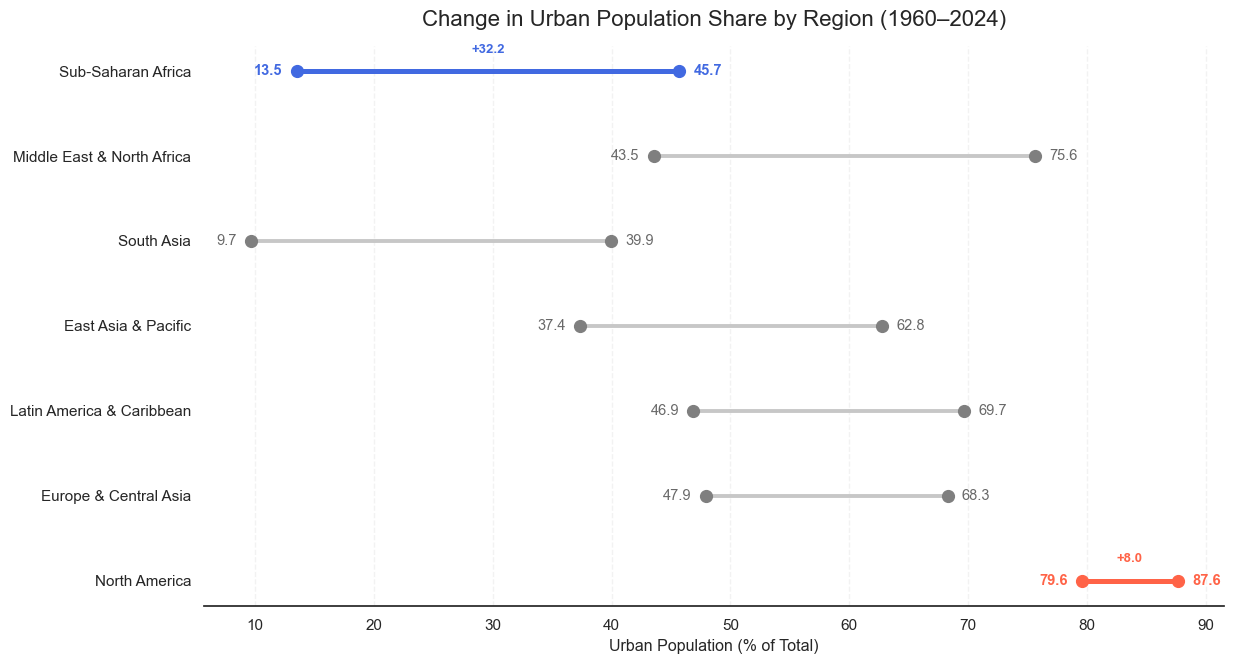

In [71]:
# Tính mức tăng đô thị hóa theo region
growth = urban_df.groupby(["Region", "Year"])["Value"].mean().reset_index()

growth_rate = growth.groupby("Region").apply(
    lambda x: x.sort_values("Year")["Value"].iloc[-1] - x.sort_values("Year")["Value"].iloc[0]
).reset_index(name="Urbanization Increase")

growth_rate = growth_rate.sort_values("Urbanization Increase", ascending=False)

display(Markdown("### Mức tăng đô thị hóa theo khu vực"))
display(growth_rate)

display(Markdown("## Dumbbell Chart: Urban Population Change by Region"))

start_year = region_year["Year"].min()
end_year = region_year["Year"].max()

start_df = (
    region_year[region_year["Year"] == start_year][["Region", "Value"]]
    .rename(columns={"Value": "Start"})
)

end_df = (
    region_year[region_year["Year"] == end_year][["Region", "Value"]]
    .rename(columns={"Value": "End"})
)

dumbbell_df = start_df.merge(end_df, on="Region")
dumbbell_df["Change"] = dumbbell_df["End"] - dumbbell_df["Start"]

# Sắp xếp theo mức tăng từ thấp đến cao để dễ đọc
dumbbell_df = dumbbell_df.sort_values("Change", ascending=True).reset_index(drop=True)

# Xác định region tăng thấp nhất và cao nhất
min_region = dumbbell_df.loc[dumbbell_df["Change"].idxmin(), "Region"]
max_region = dumbbell_df.loc[dumbbell_df["Change"].idxmax(), "Region"]

fig, ax = plt.subplots(figsize=(12.5, 6.8))

for i, row in dumbbell_df.iterrows():
    region = row["Region"]

    if region == max_region:
        line_color = "royalblue"
        point_color = "royalblue"
        line_width = 3.6
        text_weight = "bold"
    elif region == min_region:
        line_color = "tomato"
        point_color = "tomato"
        line_width = 3.6
        text_weight = "bold"
    else:
        line_color = "#c7c7c7"
        point_color = "#7f7f7f"
        line_width = 2.8
        text_weight = "normal"

    ax.plot(
        [row["Start"], row["End"]],
        [i, i],
        color=line_color,
        linewidth=line_width,
        zorder=2
    )

    ax.scatter(row["Start"], i, s=72, color=point_color, zorder=3)
    ax.scatter(row["End"], i, s=72, color=point_color, zorder=3)

    # Nhãn số bên trái
    ax.text(
        row["Start"] - 1.2,
        i,
        f"{row['Start']:.1f}",
        va="center",
        ha="right",
        fontsize=10.5,
        color=line_color if region in [min_region, max_region] else "dimgray",
        fontweight=text_weight
    )

    # Nhãn số bên phải
    ax.text(
        row["End"] + 1.2,
        i,
        f"{row['End']:.1f}",
        va="center",
        ha="left",
        fontsize=10.5,
        color=line_color if region in [min_region, max_region] else "dimgray",
        fontweight=text_weight
    )

    # Có thể thêm nhãn mức tăng ở giữa cho 2 vùng nổi bật
    if region in [min_region, max_region]:
        mid_x = (row["Start"] + row["End"]) / 2
        ax.text(
            mid_x,
            i + 0.18,
            f"{row['Change']:+.1f}",
            ha="center",
            va="bottom",
            fontsize=9.5,
            color=line_color,
            fontweight="bold"
        )

ax.set_yticks(range(len(dumbbell_df)))
ax.set_yticklabels(dumbbell_df["Region"], fontsize=11)

ax.set_title(
    f"Change in Urban Population Share by Region ({start_year}–{end_year})",
    fontsize=16,
    pad=14
)

ax.set_xlabel("Urban Population (% of Total)", fontsize=11.5)
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

**Nhận xét và insight về tốc độ tăng trưởng đô thị hóa**

**Quy luật tỷ lệ nghịch giữa xuất phát điểm và tốc độ**
- Biểu đồ xác nhận xu hướng: Các khu vực có điểm xuất phát thấp thường có **tốc độ tăng trưởng nhanh hơn**, trong khi các khu vực đã đô thị hóa cao có xu hướng **tăng chậm lại và bão hòa**.
- **North America**: Ghi nhận mức tăng thấp nhất toàn cầu. Điều này không phản ánh sự trì trệ mà là kết quả của việc đã đạt ngưỡng đô thị hóa cao ngay từ giai đoạn đầu quan sát.

---

**Sự bứt phá của các nền kinh tế đang phát triển**
- **Sub-Saharan Africa**: Là khu vực có **mức tăng trưởng lớn nhất**, minh chứng cho một cuộc dịch chuyển cơ cấu dân cư khổng lồ từ nông thôn sang thành thị trong 6 thập kỷ qua.
- **East Asia & Middle East**: Ghi nhận mức tăng ấn tượng, phản ánh tốc độ công nghiệp hóa thần tốc và sự hình thành các siêu đô thị mới trong vài thập kỷ gần đây.

---

**Sự cải thiện tại các khu vực đặc thù**
- **South Asia**: Dù đã có những bước tiến nhất định so với chính mình trong quá khứ, khu vực này vẫn duy trì mức đô thị hóa thấp tương đối so với mặt bằng chung thế giới.
- **Latin America & Europe**: Tiếp tục quỹ đạo tăng trưởng ổn định, giữ vững vị thế là những khu vực có nền tảng đô thị hóa vững chắc.

---

**Insight chính**

> Tốc độ đô thị hóa không chỉ là một con số thống kê, nó là **phản chiếu của chu kỳ phát triển kinh tế**. Thế giới đang chứng kiến sự đổi ngôi về động lực tăng trưởng: Khi các khu vực phát triển đã "đứng yên" tại đỉnh, thì các khu vực đang phát triển lại chính là những đầu tàu thúc đẩy diện mạo đô thị hóa toàn cầu trong tương lai.

#### **Biểu đồ 3: Boxplot Phân bố đô thị hóa**

**Mục tiêu**  
Phân tích phân phối tỷ lệ dân số đô thị của các khu vực theo thời gian, nhằm làm rõ mức độ phân tán, trung vị và sự khác biệt trong quá trình đô thị hóa.

**Lý do lựa chọn biểu đồ**  
- Boxplot thể hiện rõ trung vị, khoảng phân vị và độ biến động của dữ liệu  
- Giúp so sánh mức độ ổn định hoặc phân tán giữa các khu vực  
- Cho phép nhận diện sự chênh lệch không chỉ về mức độ mà còn về tính đồng đều trong đô thị hóa  
- Phù hợp để đặt các khu vực vào cùng một khung so sánh phân phối  

## Horizontal Boxplot: Distribution of Urbanization

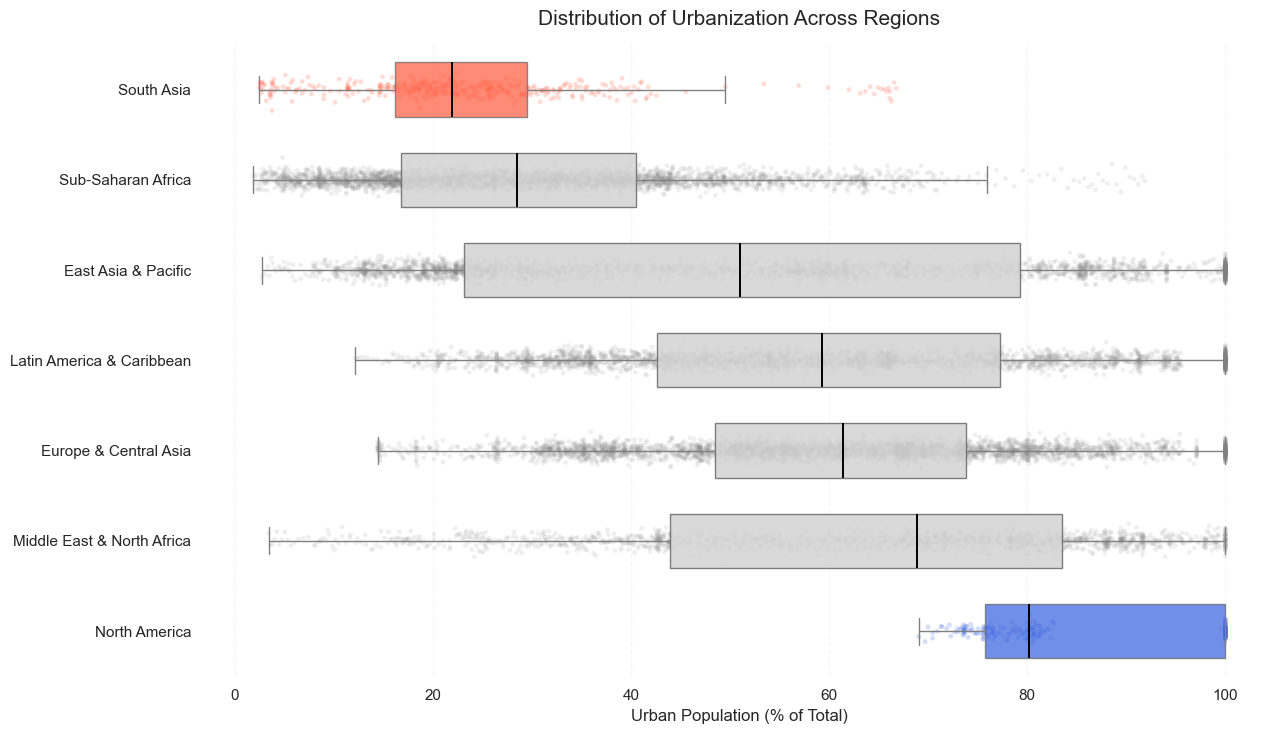

In [72]:
display(Markdown("## Horizontal Boxplot: Distribution of Urbanization"))

# Xác định vùng có median cao nhất & thấp nhất
region_medians = urban_df.groupby("Region")["Value"].median()

highest_region = region_medians.idxmax()
lowest_region = region_medians.idxmin()

median_order = (
    region_medians
    .sort_values(ascending=False)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(13, 7.5))

data_to_plot = [
    urban_df.loc[urban_df["Region"] == region, "Value"].dropna().values
    for region in median_order
]

box = ax.boxplot(
    data_to_plot,
    vert=False,
    patch_artist=True,
    labels=median_order,
    widths=0.6,
    showfliers=False
)

# Highlight BOTH highest & lowest
for patch, region in zip(box["boxes"], median_order):
    if region == highest_region:
        patch.set_facecolor("royalblue")   # cao nhất
        patch.set_alpha(0.75)
    elif region == lowest_region:
        patch.set_facecolor("tomato")      # thấp nhất
        patch.set_alpha(0.75)
    else:
        patch.set_facecolor("lightgray")
        patch.set_alpha(0.85)
        
    patch.set_edgecolor("dimgray")
    patch.set_linewidth(1.0)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(1.4)

for whisker in box["whiskers"]:
    whisker.set_color("gray")
    whisker.set_linewidth(1.0)

for cap in box["caps"]:
    cap.set_color("gray")
    cap.set_linewidth(1.0)

rng = np.random.default_rng(42)

for i, region in enumerate(median_order, start=1):
    values = urban_df.loc[urban_df["Region"] == region, "Value"].dropna().values
    y = rng.normal(loc=i, scale=0.06, size=len(values))
    
    if region == highest_region:
        ax.scatter(values, y, s=12, alpha=0.22, color="royalblue", edgecolors="none")
    elif region == lowest_region:
        ax.scatter(values, y, s=12, alpha=0.22, color="tomato", edgecolors="none")
    else:
        ax.scatter(values, y, s=12, alpha=0.12, color="gray", edgecolors="none")

# Title tổng quát hơn
ax.set_title(
    "Distribution of Urbanization Across Regions",
    fontsize=15,
    pad=14
)

ax.set_xlabel("Urban Population (% of Total)", fontsize=12)
ax.set_ylabel("")

ax.grid(axis="x", linestyle="--", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()

**Nhận xét và insight về phân phối đô thị hóa**

**Sự ổn định ở nhóm dẫn đầu**
- **North America**: Sở hữu mức đô thị hóa cao tuyệt đối với **khoảng phân phối cực hẹp**. Điều này minh chứng cho một cấu trúc đô thị đã hoàn thiện, ổn định và hầu như không còn biến động lớn theo thời gian.
- **Europe & Latin America**: Ghi nhận mức trung vị (median) cao và hình thái phân phối cân bằng, cho thấy sự phát triển đồng bộ và ổn định trong tiến trình đô thị hóa.

---

**Sự biến động mạnh ở các nhóm chuyển đổi**
- **East Asia & Middle East:** Thể hiện **độ phân tán (IQR) rộng nhất**, minh chứng cho sự **phân hóa nội khối sâu sắc** khi khu vực này chứa cả những quốc gia đã siêu đô thị hóa lẫn các nước vẫn đang ở giai đoạn đầu của công nghiệp hóa."
- **Sub-Saharan Africa:** Có độ phân tán lớn nhưng nằm ở ngưỡng thấp, phản ánh **sự chênh lệch lớn về nguồn lực và hạ tầng** giữa các quốc gia trong cùng một khu vực."

---

**Nhóm tăng trưởng chậm đặc thù**
- **South Asia**: Duy trì mức đô thị hóa thấp với khoảng phân phối hẹp. Điều này cho thấy tốc độ chuyển dịch tại đây diễn ra **chậm nhưng có tính nhất quán cao**, chưa có sự bứt phá mạnh mẽ về tỷ lệ dân cư thành thị.

---

**Insight chính**

> Biểu đồ phân phối xác nhận một quy luật: **Mức độ đô thị hóa tỉ lệ thuận với độ ổn định.** Các khu vực phát triển đã "đóng khung" được cấu trúc đô thị, trong khi các khu vực đang phát triển (Đông Á, Phi cận Sahara) vẫn đang nằm trong giai đoạn biến động mạnh, chứa đựng cả cơ hội bứt phá lẫn rủi ro về mất cân bằng hạ tầng.

#### **Biểu đồ 4: Slopegraph: Phân bố tỷ lệ dân số đô thị theo khu vực -  Xem khu vực nào tăng nhanh nhất**

**Mục tiêu**  
So sánh trực tiếp mức đô thị hóa giữa hai thời điểm (1960 và 2024) theo từng khu vực, đồng thời làm nổi bật sự thay đổi về thứ hạng và khoảng cách giữa các khu vực.

**Lý do lựa chọn biểu đồ**  
- Slopegraph giúp kết nối trực quan hai mốc thời gian, làm rõ xu hướng thay đổi  
- Cho phép theo dõi đồng thời mức độ và hướng thay đổi của từng khu vực  
- Dễ nhận diện sự thay đổi thứ hạng giữa các khu vực qua thời gian  
- Hiệu quả trong việc kể câu chuyện về hội tụ hoặc phân kỳ giữa các nhóm  

## Slopegraph: Distribution of Urban Population Share by Region

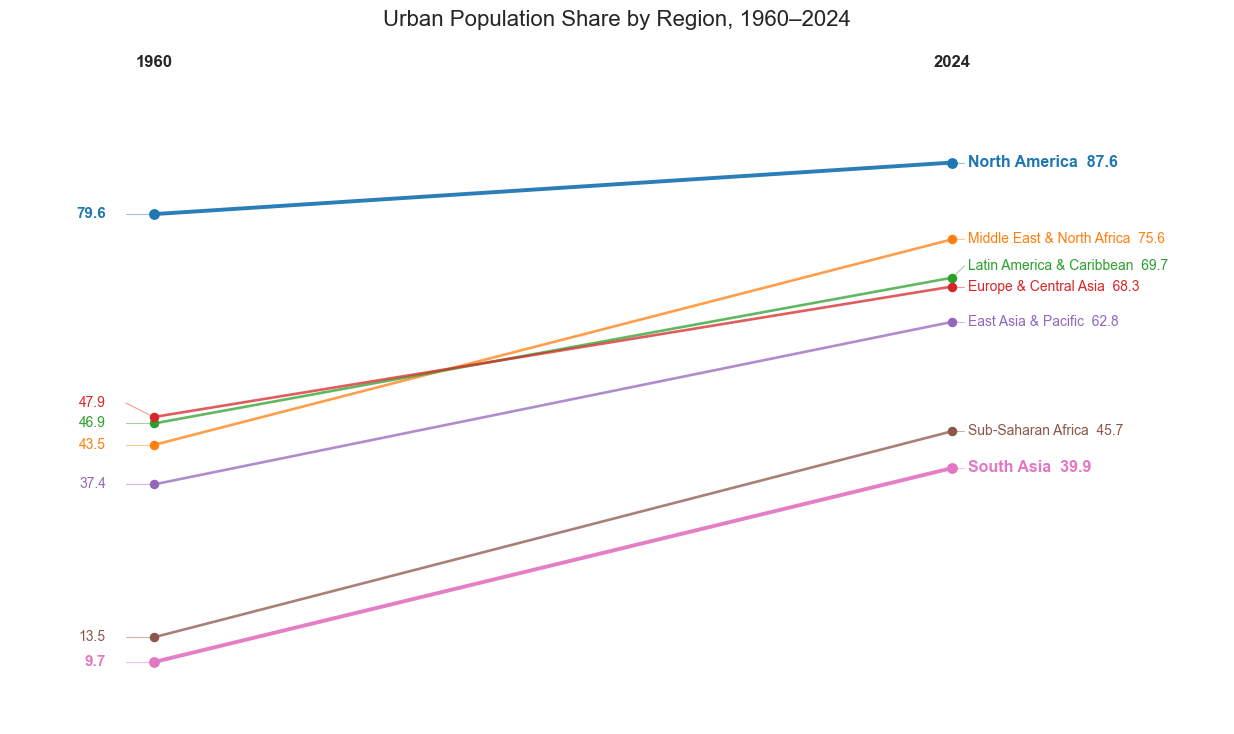

In [73]:
display(Markdown("## Slopegraph: Distribution of Urban Population Share by Region"))

start_year = 1960
end_year = 2024

slope_df = (
    region_year[region_year["Year"].isin([start_year, end_year])]
    .pivot(index="Region", columns="Year", values="Value")
    .dropna()
    .reset_index()
)

slope_df = slope_df.sort_values(end_year, ascending=False).reset_index(drop=True)

# Xác định max / min theo năm cuối
max_region = slope_df.loc[slope_df[end_year].idxmax(), "Region"]
min_region = slope_df.loc[slope_df[end_year].idxmin(), "Region"]

# Mỗi region một màu
cmap = plt.get_cmap("tab10")
region_colors = {
    region: cmap(i % 10)
    for i, region in enumerate(slope_df["Region"])
}

# Hàm giãn label để tránh chồng lấn
def spread_positions(values, min_gap=3.0, lower=0, upper=100):
    positions = sorted(values)
    adjusted = positions.copy()

    # đẩy lên phía trên nếu quá sát
    for i in range(1, len(adjusted)):
        if adjusted[i] - adjusted[i - 1] < min_gap:
            adjusted[i] = adjusted[i - 1] + min_gap

    # nếu vượt upper thì kéo ngược xuống
    if adjusted[-1] > upper:
        adjusted[-1] = upper
        for i in range(len(adjusted) - 2, -1, -1):
            adjusted[i] = min(adjusted[i], adjusted[i + 1] - min_gap)

    # nếu thấp hơn lower thì đẩy lại lên
    if adjusted[0] < lower:
        adjusted[0] = lower
        for i in range(1, len(adjusted)):
            adjusted[i] = max(adjusted[i], adjusted[i - 1] + min_gap)

    return adjusted

fig, ax = plt.subplots(figsize=(12.5, 7.5))

x_start, x_end = 0, 1

# Vị trí label trái/phải đã giãn
left_sorted = slope_df[[start_year, "Region"]].sort_values(start_year)
right_sorted = slope_df[[end_year, "Region"]].sort_values(end_year)

left_positions = spread_positions(left_sorted[start_year].tolist(), min_gap=3.2, lower=2, upper=98)
right_positions = spread_positions(right_sorted[end_year].tolist(), min_gap=3.2, lower=2, upper=98)

left_label_y = dict(zip(left_sorted["Region"], left_positions))
right_label_y = dict(zip(right_sorted["Region"], right_positions))

for _, row in slope_df.iterrows():
    region = row["Region"]
    y_start = row[start_year]
    y_end = row[end_year]

    is_extreme = region in [max_region, min_region]

    line_color = region_colors[region]
    line_width = 2.8 if is_extreme else 1.9
    alpha = 0.95 if is_extreme else 0.75

    # line chính
    ax.plot(
        [x_start, x_end],
        [y_start, y_end],
        color=line_color,
        linewidth=line_width,
        alpha=alpha,
        zorder=3 if is_extreme else 2
    )

    # điểm đầu/cuối
    ax.scatter(
        [x_start, x_end],
        [y_start, y_end],
        color=line_color,
        s=46 if is_extreme else 34,
        zorder=4
    )

    # đường nối mảnh ra label bên trái
    ax.plot(
        [x_start, x_start - 0.035],
        [y_start, left_label_y[region]],
        color=line_color,
        linewidth=0.8,
        alpha=0.45
    )

    # đường nối mảnh ra label bên phải
    ax.plot(
        [x_end, x_end + 0.015],
        [y_end, right_label_y[region]],
        color=line_color,
        linewidth=0.8,
        alpha=0.45
    )

    # số bên trái
    ax.text(
        x_start - 0.06,
        left_label_y[region],
        f"{y_start:.1f}",
        ha="right",
        va="center",
        fontsize=11 if is_extreme else 10,
        fontweight="semibold" if is_extreme else "normal",
        color=line_color
    )

    # tên vùng + số bên phải
    ax.text(
        x_end + 0.02,
        right_label_y[region],
        f"{region}  {y_end:.1f}",
        ha="left",
        va="center",
        fontsize=11.5 if is_extreme else 10,
        fontweight="semibold" if is_extreme else "normal",
        color=line_color
    )

# Nhãn năm
ax.text(
    x_start, 102, str(start_year),
    ha="center", va="bottom",
    fontsize=12, fontweight="bold"
)
ax.text(
    x_end, 102, str(end_year),
    ha="center", va="bottom",
    fontsize=12, fontweight="bold"
)

# Tiêu đề tổng quát hơn
ax.set_title(
    "Urban Population Share by Region, 1960–2024",
    fontsize=16,
    pad=18
)

ax.set_xlim(-0.18, 1.34)
ax.set_ylim(0, 105)

ax.set_xticks([])
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()

**Nhận xét và insight về cấu trúc đô thị hóa (1960–2024)**

**Sự thống trị và ổn định của nhóm dẫn đầu**
- **North America**: Giữ vững vị trí quán quân xuyên suốt hơn 6 thập kỷ. Với mức đô thị hóa cao nhất và tốc độ tăng trưởng ổn định, khu vực này đại diện cho trạng thái phát triển bão hòa.
- **Latin America & Europe**: Duy trì phong độ ở nhóm "cận cao", đóng vai trò là các trục đô thị hóa truyền thống với sự tăng trưởng bền vững qua các năm.

---

**Những cú bứt phá về vị thế**
- **Middle East & North Africa**: Ghi nhận sự thăng hạng mạnh mẽ, vươn lên vượt qua nhiều khu vực để gia nhập nhóm có tỷ lệ đô thị hóa cao nhất toàn cầu.
- **East Asia & Pacific**: Là điểm sáng về tốc độ cải thiện. Khu vực này đã thu hẹp khoảng cách với các nước phát triển một cách ngoạn mục, phản ánh làn sóng công nghiệp hóa thần tốc.

---

**Thách thức tại các "vùng trũng" đô thị**
- **South Asia & Sub-Saharan Africa**: Dù đã có những bước tiến dài so với chính mình năm 1960, đây vẫn là hai khu vực nằm ở đáy biểu đồ. 
- **Insight**: Sự phân tầng vẫn hiện hữu rõ rệt giữa nhóm quốc gia phát triển và đang phát triển, cho thấy lộ trình đô thị hóa tại các khu vực này vẫn còn rất nhiều dư địa nhưng cũng đầy rẫy rào cản kinh tế.

---

**Insight chính**

> Bức tranh đô thị hóa toàn cầu đang có xu hướng **"hội tụ"**: Khoảng cách giữa các châu lục đang dần thu hẹp. Tuy nhiên, sự phân hóa thứ bậc vẫn tồn tại, chia thế giới thành ba tầng rõ rệt: Nhóm bão hòa (Bắc Mỹ), Nhóm bứt phá (Đông Á, Trung Đông) và Nhóm đang chuyển dịch (Nam Á, Phi cận Sahara).

### **Bước 3: Nhận xét chung**

Các biểu đồ cho thấy tỷ lệ dân số sống ở đô thị đã tăng ở tất cả các khu vực trong giai đoạn 1960–2024, nhưng tốc độ và mức độ đô thị hóa không giống nhau. Nhìn chung, **Bắc Mỹ** luôn là khu vực có mức đô thị hóa cao nhất và đến năm 2024 đã ở trạng thái gần bão hòa, nên mức tăng thêm không lớn. **Châu Âu & Trung Á** và **Mỹ Latinh & Caribe** cũng duy trì tỷ lệ đô thị hóa cao, cho thấy quá trình chuyển dịch sang đô thị đã diễn ra từ sớm.

Trong khi đó, các khu vực có **mức tăng mạnh nhất** là **Châu Phi hạ Sahara** và **Trung Đông & Bắc Phi**, phản ánh quá trình đô thị hóa diễn ra nhanh trong nhiều thập kỷ gần đây. **Nam Á** cũng tăng đáng kể, nhưng vẫn là khu vực có tỷ lệ đô thị hóa thấp nhất vào năm 2024, cho thấy dư địa đô thị hóa còn lớn. **Đông Á & Thái Bình Dương** có bước tiến rõ rệt, phù hợp với quá trình công nghiệp hóa và tăng trưởng kinh tế mạnh trong giai đoạn sau.

Biểu đồ phân bố cũng cho thấy sự khác biệt nội vùng khá lớn ở một số khu vực, đặc biệt là **Châu Phi hạ Sahara** và **Đông Á & Thái Bình Dương**, nghĩa là các quốc gia trong cùng khu vực không đô thị hóa đồng đều. Ngược lại, **Bắc Mỹ** có phân bố tập trung và ổn định hơn, phản ánh mức đô thị hóa cao và ít biến động giữa các quốc gia.

Tóm lại, bức tranh chung cho thấy thế giới ngày càng đô thị hóa mạnh hơn, nhưng các khu vực đang ở những giai đoạn khác nhau của quá trình này: có nơi đã gần đạt ngưỡng bão hòa, còn có nơi vẫn đang tăng nhanh và tiếp tục chuyển dịch mạnh từ nông thôn sang đô thị.

> **$\Rightarrow$ Sub-Saharan Africa (Châu Phi hạ Sahara) là khu vực có tốc độ đô thị hóa nhanh nhất (tăng nhiều nhất về tỷ lệ), rất sát với Middle East & North Africa., nơi người dân dịch chuyển mạnh từ nông thôn lên thành thị nhằm tìm kiếm cơ hội kinh tế và cải thiện điều kiện sống.**

> **$\Rightarrow$ North America (Bắc Mỹ) là khu vực đô thị hóa cao nhất thế giới**

## **Câu hỏi 3: Bình đẳng giới trong lao động - Tỷ lệ phụ nữ tham gia làm việc so với nam giới chênh lệch ra sao? Khu vực nào có sự bất bình đẳng giới lớn nhất?**

### **Bước 1: Xử lý dữ liệu:**

Lọc các indicator cần thiết: 
- Female labor force participation rate (%)
- Male labor force participation rate (%)

In [74]:
female_indicator = "Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)"
male_indicator = "Labor force participation rate, male (% of male population ages 15+) (modeled ILO estimate)"

# Chạy lại phần lọc
df_gender = df[df["Indicator Name"].isin([female_indicator, male_indicator])].copy()

# Pivot dữ liệu
df_pivot = df_gender.pivot_table(
    index=["Country Name", "Year", "Region", "Income Group"],
    columns="Indicator Name",
    values="Value"
).reset_index()

# Đổi tên cột cho ngắn gọn
df_pivot = df_pivot.rename(columns={
    female_indicator: "Female",
    male_indicator: "Male"
})

# Tính Gap (Giờ chắc chắn sẽ chạy được)
df_pivot["Gap"] = df_pivot["Male"] - df_pivot["Female"]

# Hiển thị kết quả
display(df_pivot.head())

Indicator Name,Country Name,Year,Region,Income Group,Female,Male,Gap
0,Afghanistan,1990,Middle East & North Africa,Low income,15.739,80.000,64.261
1,Afghanistan,1991,Middle East & North Africa,Low income,15.695,80.002,64.307
2,Afghanistan,1992,Middle East & North Africa,Low income,15.618,80.025,64.407
3,Afghanistan,1993,Middle East & North Africa,Low income,15.506,80.000,64.494
4,Afghanistan,1994,Middle East & North Africa,Low income,15.358,79.960,64.602


In [75]:
# Dữ liệu năm mới nhất
latest_year = df_pivot["Year"].max()
df_latest = (
    df_pivot
    .dropna(subset=["Gap"])
    .loc[df_pivot["Year"] == df_pivot["Year"].max()]
    .copy()
)
display(Markdown(f"### Năm mới nhất trong dataset: **{latest_year}**"))

### Năm mới nhất trong dataset: **2025**

### **Bước 2: Phân tích & Trực quan hóa**

#### **Biểu đồ 1: Line Chart - Xu hướng toàn cầu theo thời gian**

**Mục tiêu**

Biểu đồ này nhằm:
- Theo dõi **xu hướng tham gia lực lượng lao động toàn cầu** theo thời gian
- So sánh sự khác biệt giữa **Nam** và **Nữ**
- Phát hiện các **biến động bất thường** (ví dụ: năm 2020)

---

**Lý do chọn biểu đồ đường (Line Chart)**

- Phù hợp với dữ liệu **chuỗi thời gian (time series)**
- Giúp nhận diện **xu hướng liên tục** một cách trực quan
- Tận dụng nguyên tắc **"connection"** → mắt người dễ theo dõi sự thay đổi
- So sánh hai nhóm (**Nam vs Nữ**) trên cùng một trục rất hiệu quả

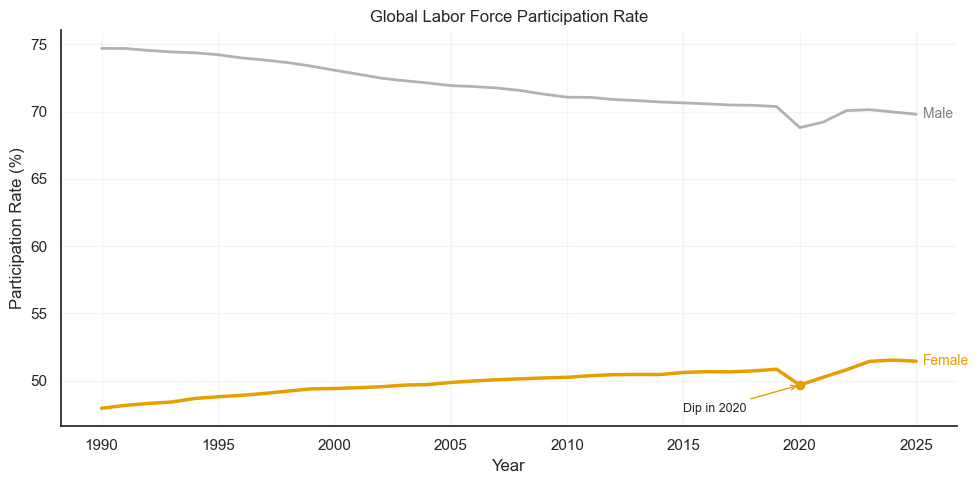

In [76]:
df_global = df_pivot.groupby("Year")[["Male", "Female"]].mean().reset_index()

plt.figure(figsize=(10,5))

# Line chính (highlight) – Female
plt.plot(
    df_global["Year"], df_global["Female"],
    color="#E69F00", linewidth=2.5, label="Female"
)

# Line phụ (fade) – Male
plt.plot(
    df_global["Year"], df_global["Male"],
    color="gray", linewidth=2, alpha=0.6, label="Male"
)

# Title & labels (giữ nguyên)
plt.title("Global Labor Force Participation Rate")
plt.xlabel("Year")
plt.ylabel("Participation Rate (%)")

# Bỏ legend → thay bằng label trực tiếp
plt.text(df_global["Year"].iloc[-1]+0.3,
         df_global["Female"].iloc[-1],
         "Female", color="#E69F00", fontsize=10, va="center")

plt.text(df_global["Year"].iloc[-1]+0.3,
         df_global["Male"].iloc[-1],
         "Male", color="gray", fontsize=10, va="center")

# Highlight nhẹ điểm 2020 (ví dụ insight)
year_2020 = df_global[df_global["Year"] == 2020]
if not year_2020.empty:
    x = year_2020["Year"].values[0]
    y = year_2020["Female"].values[0]
    plt.scatter(x, y, color="#E69F00", zorder=5)
    plt.annotate(
        "Dip in 2020",
        (x, y),
        xytext=(x-5, y-2),
        arrowprops=dict(arrowstyle="->", color="#E69F00"),
        fontsize=9
    )

# Grid nhẹ hơn
plt.grid(alpha=0.2)

# Loại bỏ viền trên & phải (clean hơn)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Nhận xét và insight từ biểu đồ**

**Xu hướng tổng thể**
- Tỷ lệ tham gia của **Nam** có xu hướng giảm nhẹ theo thời gian  
- Tỷ lệ tham gia của **Nữ** tăng chậm nhưng ổn định  

---

**Khoảng cách giới (Gender Gap)**
- Khoảng cách giữa Nam và Nữ vẫn duy trì ở mức cao (~20%)  
- Sự gia tăng của Nữ chưa đủ mạnh để thu hẹp khoảng cách đáng kể  

---

**Biến động đáng chú ý**
- Năm 2020 xuất hiện một điểm sụt giảm rõ rệt  
- Xu hướng này có khả năng liên quan đến các cú sốc toàn cầu (ví dụ: đại dịch)  
- Sau đó có dấu hiệu phục hồi nhưng chưa hoàn toàn trở lại xu hướng cũ  

---

**Insight chính**

> Tỷ lệ tham gia của Nữ đang cải thiện theo thời gian, nhưng tốc độ tăng chậm khiến khoảng cách giới vẫn tồn tại như một vấn đề dài hạn  

#### **Biểu đồ 2: Small Multiples - Khoảng cách giới tính trong tham gia lao động từng khu vực**

**Mục tiêu của biểu đồ**

- So sánh **xu hướng tham gia lực lượng lao động theo giới tính** giữa các khu vực trên thế giới  
- Phân tích sự khác biệt về **khoảng cách giới (gender gap)** theo không gian (khu vực) và thời gian  
- Xác định khu vực có **tiến bộ nhanh** hoặc **bất bình đẳng kéo dài**  

---

**Lý do lựa chọn Small Multiples (Faceted Line Chart)**

- Cho phép so sánh nhiều khu vực **trong cùng một cấu trúc trực quan**  
- Mỗi biểu đồ nhỏ giữ cùng thang đo → đảm bảo **so sánh công bằng (common scale)**  
- Giảm sự chồng chéo dữ liệu so với việc vẽ tất cả trên một biểu đồ  
- Tận dụng nguyên tắc **so sánh song song (parallel comparison)** để phát hiện khác biệt

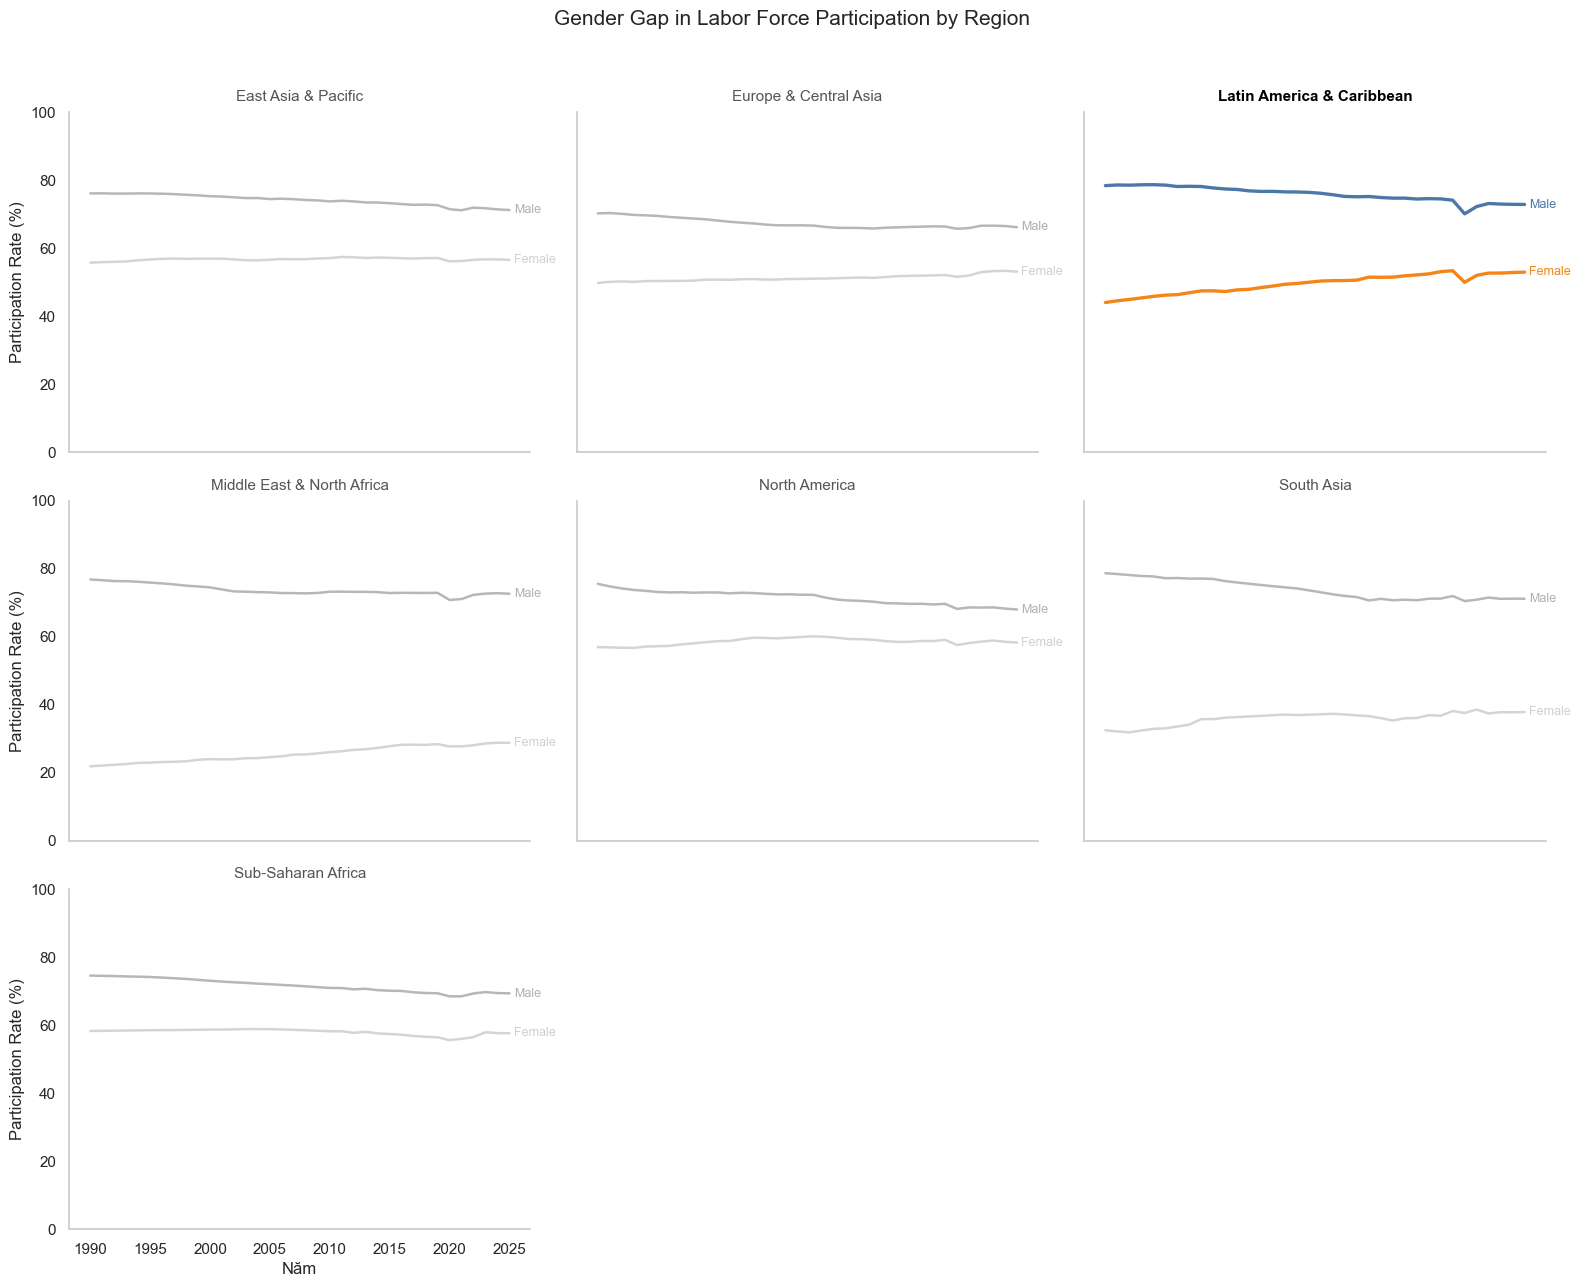

In [77]:
df_region = (
    df_pivot.groupby(["Region", "Year"])[["Male", "Female", "Gap"]]
    .mean()
    .reset_index()
)

# Danh sách khu vực
regions = sorted(df_region["Region"].dropna().unique())
n_regions = len(regions)

# Chọn khu vực highlight

gap_summary = (
    df_region.sort_values("Year")
    .groupby("Region")
    .agg(
        gap_start=("Gap", "first"),
        gap_end=("Gap", "last")
    )
    .reset_index()
)

gap_summary["gap_reduction"] = gap_summary["gap_start"] - gap_summary["gap_end"]
highlight_region = gap_summary.loc[gap_summary["gap_reduction"].idxmax(), "Region"]

# Thiết lập small multiples
ncols = 3
nrows = math.ceil(n_regions / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 4.2 * nrows),
    sharex=True,
    sharey=True
)

# Khi chỉ có 1 hàng / 1 cột, chuẩn hóa axes thành mảng 2D
if nrows == 1 and ncols == 1:
    axes = [[axes]]
elif nrows == 1:
    axes = [axes]
elif ncols == 1:
    axes = [[ax] for ax in axes]

# Màu sắc
highlight_male = "#4C78A8"
highlight_female = "#F58518"
normal_male = "#B0B0B0"
normal_female = "#D0D0D0"

# Common scale
ymin, ymax = 0, 100

# Vẽ từng biểu đồ nhỏ
for i, region in enumerate(regions):
    r = i // ncols
    c = i % ncols
    ax = axes[r][c]

    data_r = df_region[df_region["Region"] == region].sort_values("Year")

    is_highlight = (region == highlight_region)

    male_color = highlight_male if is_highlight else normal_male
    female_color = highlight_female if is_highlight else normal_female
    lw = 2.4 if is_highlight else 1.8
    alpha = 1.0 if is_highlight else 0.9

    # Đường biểu diễn trôi chảy, không marker để mắt tập trung vào xu hướng
    ax.plot(
        data_r["Year"], data_r["Male"],
        color=male_color, linewidth=lw, alpha=alpha
    )
    ax.plot(
        data_r["Year"], data_r["Female"],
        color=female_color, linewidth=lw, alpha=alpha
    )

    # Tiêu đề từng ô = tên khu vực (direct labeling thay cho legend chung)
    ax.set_title(region, fontsize=11, pad=8,
                 color="black" if is_highlight else "#555555",
                 fontweight="bold" if is_highlight else "normal")

    # Common scale
    ax.set_ylim(ymin, ymax)

    # Grid rất nhẹ hoặc tắt hẳn
    ax.grid(False)

    # Direct label ở điểm cuối cùng
    last_row = data_r.iloc[-1]
    x_last = last_row["Year"]
    male_last = last_row["Male"]
    female_last = last_row["Female"]

    ax.text(
        x_last + 0.35, male_last, "Male",
        color=male_color, fontsize=9, va="center"
    )
    ax.text(
        x_last + 0.35, female_last, "Female",
        color=female_color, fontsize=9, va="center"
    )

    # Chỉ giữ nhãn Y ở biểu đồ đầu tiên bên trái mỗi hàng
    if c == 0:
        ax.set_ylabel("Participation Rate (%)")
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", left=False, labelleft=False)

    # Chỉ giữ nhãn X ở hàng dưới cùng
    if r == nrows - 1:
        ax.set_xlabel("Năm")
    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", bottom=False, labelbottom=False)

    # Giảm clutter: bỏ viền trên/phải
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Làm viền trái/dưới nhẹ hơn
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")

# Xóa các ô thừa nếu số khu vực không chia hết cho ncols
for j in range(n_regions, nrows * ncols):
    r = j // ncols
    c = j % ncols
    fig.delaxes(axes[r][c])

# Tiêu đề
fig.suptitle(
    "Gender Gap in Labor Force Participation by Region",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

**Nhận xét và insight từ biểu đồ**

**Sự khác biệt giữa các khu vực**
- **Latin America & Caribbean** nổi bật với xu hướng **thu hẹp khoảng cách giới rõ rệt**  
- **Middle East & North Africa** duy trì khoảng cách rất lớn, dù có cải thiện nhẹ  
- **South Asia** và **Sub-Saharan Africa** có xu hướng cải thiện nhưng vẫn còn chênh lệch đáng kể  

---

**Xu hướng chung**
- Tỷ lệ tham gia của **Nam** có xu hướng giảm nhẹ hoặc ổn định  
- Tỷ lệ tham gia của **Nữ** tăng ở hầu hết các khu vực, nhưng tốc độ không đồng đều  

---

**Khoảng cách giới (Gender Gap)**
- Các khu vực phát triển hơn (như **North America**, **Europe & Central Asia**) có khoảng cách nhỏ hơn  
- Các khu vực đang phát triển vẫn tồn tại khoảng cách lớn và bền vững theo thời gian  

---

**Biến động đáng chú ý**
- Nhiều khu vực xuất hiện sự gián đoạn quanh năm 2020  
- Xu hướng phục hồi sau đó không đồng đều giữa các khu vực  

---

**Insight chính**

> Khoảng cách giới trong lực lượng lao động không chỉ là vấn đề toàn cầu mà còn mang tính khu vực rõ rệt; một số khu vực đã cải thiện đáng kể, trong khi những khu vực khác vẫn đối mặt với bất bình đẳng kéo dài  

#### **Biểu đồ 3: Bar Chart - So sánh theo khu vực**

**Mục tiêu của biểu đồ**

Biểu đồ này nhằm:
- Thể hiện **mức độ chênh lệch giới (gender gap)** trong lực lượng lao động theo thời gian và khu vực  
- Giúp nhận diện nhanh các khu vực có **khoảng cách cao, trung bình và thấp**  
- Quan sát sự thay đổi của gap theo **xu hướng dài hạn**  

---

**Lý do lựa chọn Heatmap**

- Phù hợp để biểu diễn dữ liệu dạng **ma trận (Region × Year)**  
- Cho phép người xem nhận diện **pattern và xu hướng** thông qua màu sắc  
- Hiệu quả khi cần so sánh **nhiều nhóm và nhiều thời điểm cùng lúc**  
- Giảm độ phức tạp so với việc vẽ nhiều biểu đồ riêng lẻ   

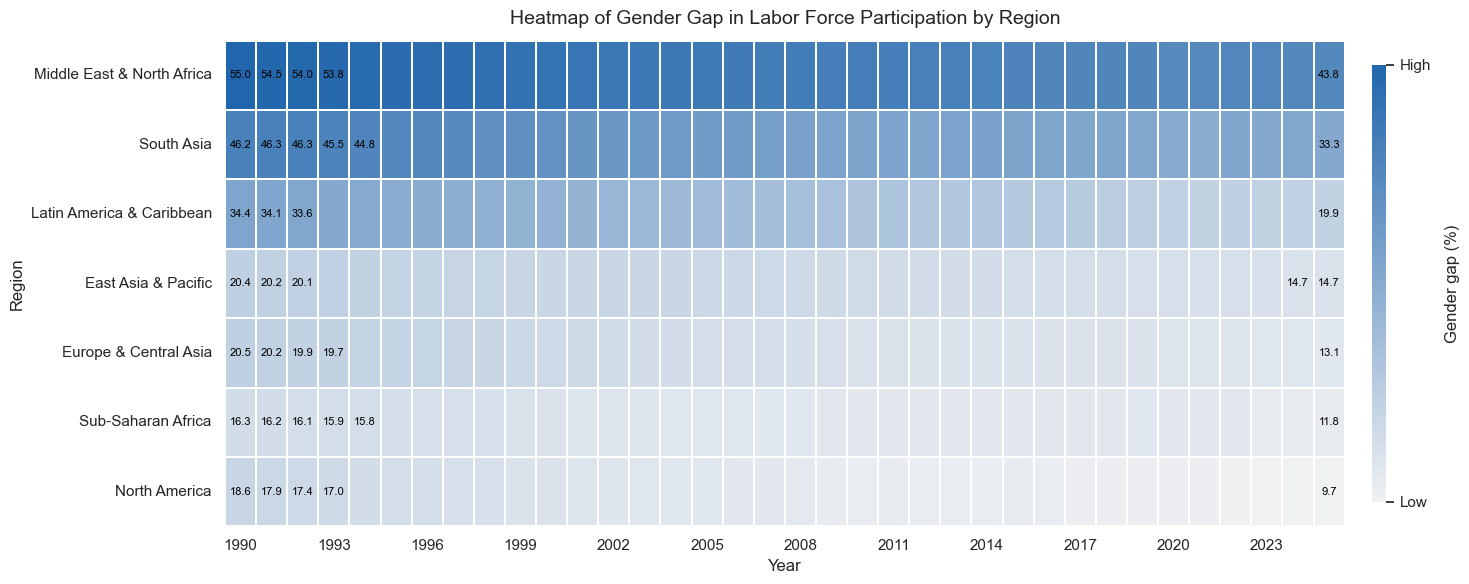

In [78]:
# Tổng hợp gender gap theo Region x Year
df_gap_region = (
    df_pivot.groupby(["Region", "Year"], as_index=False)["Gap"]
    .mean()
)

# Pivot thành ma trận heatmap
heatmap_data = df_gap_region.pivot(
    index="Region",
    columns="Year",
    values="Gap"
)

# Sắp xếp năm tăng dần
heatmap_data = heatmap_data.reindex(sorted(heatmap_data.columns), axis=1)

# Sort khu vực theo logic
region_order = heatmap_data.mean(axis=1).sort_values(ascending=False).index
heatmap_data = heatmap_data.loc[region_order]

# Tạo bảng annotation có chọn lọc
# - năm đầu
# - năm cuối
# - ô đột biến theo từng khu vực
annot_data = pd.DataFrame(
    "",
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

first_year = heatmap_data.columns.min()
last_year = heatmap_data.columns.max()

# Gắn nhãn năm đầu và năm cuối
for region in heatmap_data.index:
    if pd.notna(heatmap_data.loc[region, first_year]):
        annot_data.loc[region, first_year] = f"{heatmap_data.loc[region, first_year]:.1f}"
    if pd.notna(heatmap_data.loc[region, last_year]):
        annot_data.loc[region, last_year] = f"{heatmap_data.loc[region, last_year]:.1f}"

# Gắn nhãn thêm cho các điểm đột biến
# dùng z-score trong từng hàng (từng khu vực)
for region in heatmap_data.index:
    row = heatmap_data.loc[region]
    row_non_null = row.dropna()

    if len(row_non_null) >= 3 and row_non_null.std() > 0:
        z_scores = (row_non_null - row_non_null.mean()) / row_non_null.std()
        outlier_years = z_scores[np.abs(z_scores) >= 1.5].index

        for year in outlier_years:
            if annot_data.loc[region, year] == "":
                annot_data.loc[region, year] = f"{heatmap_data.loc[region, year]:.1f}"

# Thiết lập style
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(16, max(6, len(heatmap_data) * 0.5)))

# Sequential palette đơn sắc
cmap = sns.light_palette("#2166ac", as_cmap=True)

# Có thể cố định miền màu để dễ so sánh
vmin = np.nanmin(heatmap_data.values)
vmax = np.nanmax(heatmap_data.values)

hm = sns.heatmap(
    heatmap_data,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    annot=annot_data,
    fmt="",
    annot_kws={"fontsize": 8, "color": "black"},
    linewidths=0.3,
    linecolor="white",
    cbar=True,
    cbar_kws={
        "shrink": 0.9,
        "pad": 0.02,     # sát biểu đồ hơn
        "aspect": 30
    },
    ax=ax
)

# Tối giản bảng chú giải màu
cbar = hm.collections[0].colorbar
cbar.set_label("Gender gap (%)", rotation=90, labelpad=10)
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels(["Low", "High"])

# Nhãn và bố cục
ax.set_title("Heatmap of Gender Gap in Labor Force Participation by Region", fontsize=14, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Region")

# Chỉ hiện một phần nhãn năm nếu quá dày
years = heatmap_data.columns.tolist()
step = max(1, len(years) // 12)
ax.set_xticks(np.arange(len(years)) + 0.5)
ax.set_xticklabels(
    [str(y) if i % step == 0 else "" for i, y in enumerate(years)],
    rotation=0
)

# Làm nhãn khu vực gọn hơn
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Bỏ viền ngoài cho sạch
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

**Nhận xét và insight từ biểu đồ**

**Phân cấp rõ ràng giữa các khu vực**
- **Middle East & North Africa** luôn duy trì mức gap cao nhất  
- **South Asia** và **Latin America & Caribbean** ở mức trung bình nhưng có xu hướng cải thiện  
- **North America** và **Sub-Saharan Africa** có mức gap thấp hơn đáng kể  

---

**Xu hướng theo thời gian**
- Hầu hết các khu vực đều có xu hướng **giảm dần khoảng cách giới**  
- Sự cải thiện diễn ra **chậm và không đồng đều** giữa các khu vực  

---

**Insight chính**

> Khoảng cách giới trong lực lượng lao động có xu hướng giảm trên toàn cầu, nhưng vẫn tồn tại sự phân hóa mạnh giữa các khu vực, đặc biệt là tại **`Middle East & North Africa `**

#### **Biểu đồ 4: Boxplot - Phân bố chênh lệch theo khu vực thời điểm**

**Mục tiêu của biểu đồ**
- So sánh **phân bố khoảng cách giới (gender gap)** giữa các khu vực trong năm 2025  
- Đánh giá mức độ **chênh lệch và biến động nội bộ** trong từng khu vực  
- Xác định khu vực có **gap cao, thấp và phân tán mạnh**  

---

**Lý do lựa chọn Boxplot**

- Phù hợp để thể hiện **phân bố dữ liệu** thay vì chỉ giá trị trung bình  
- Cho phép quan sát:
  - Median (giá trị điển hình)  
  - IQR (mức độ phân tán)  
  - Outliers (giá trị bất thường)  
- Giúp so sánh giữa các khu vực trên cùng một thang đo → đảm bảo tính công bằng  

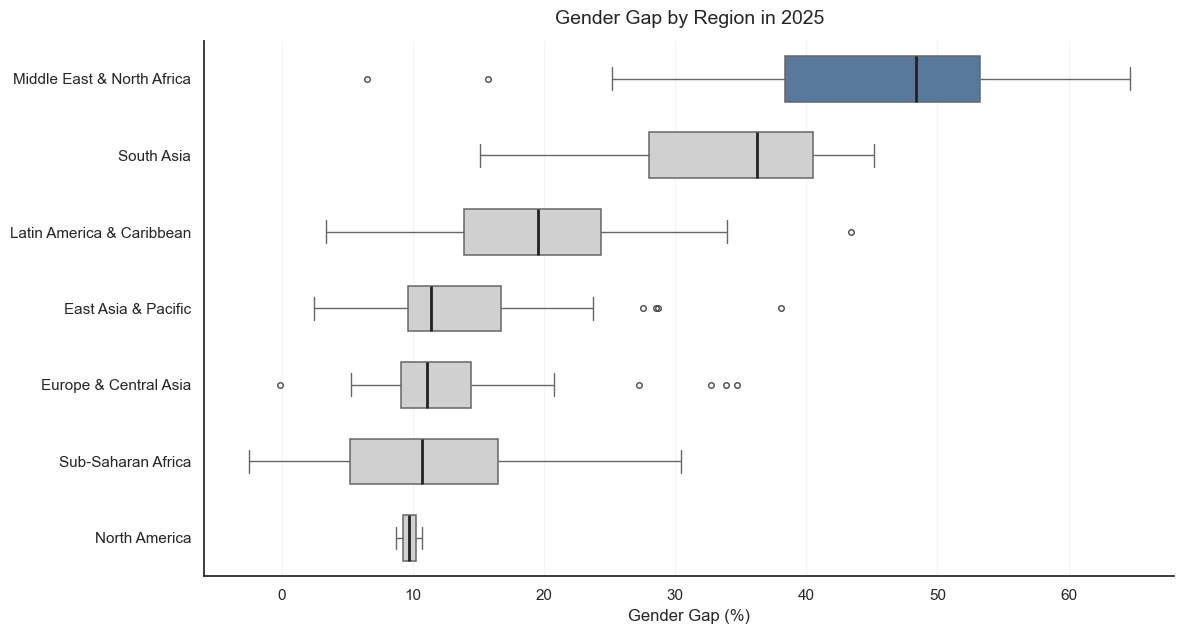

In [79]:
# df_latest giả định đã là dữ liệu của năm mới nhất
df_box = df_latest[["Region", "Gap"]].dropna().copy()

region_order = (
    df_box.groupby("Region")["Gap"]
    .median()
    .sort_values(ascending=False)
    .index
)

highlight_region = region_order[0]

palette = {region: "#D0D0D0" for region in region_order}
palette[highlight_region] = "#4C78A8"

plt.figure(figsize=(12, 6.5))
ax = sns.boxplot(
    data=df_box,
    y="Region",
    x="Gap",
    order=region_order,
    palette=palette,
    width=0.6,
    fliersize=4,
    linewidth=1.1,
    medianprops={"color": "#222222", "linewidth": 2},
    whiskerprops={"color": "#666666", "linewidth": 1},
    capprops={"color": "#666666", "linewidth": 1},
    boxprops={"edgecolor": "#666666"},
)

ax.set_title("Gender Gap by Region in 2025", fontsize=14, pad=12)
ax.set_xlabel("Gender Gap (%)")
ax.set_ylabel("")

ax.xaxis.grid(True, alpha=0.2)
ax.yaxis.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

**Nhận xét và insight từ biểu đồ**

**Phân cấp giữa các khu vực**
- **Middle East & North Africa** có mức gap cao nhất và phân bố rộng  
- **South Asia** đứng thứ hai với mức gap cao nhưng ổn định hơn  
- **North America** có gap thấp nhất và phân bố rất hẹp  

---

**Mức độ biến động**
- Một số khu vực như **Sub-Saharan Africa** và **Latin America & Caribbean** có độ phân tán lớn → sự khác biệt đáng kể giữa các quốc gia  
- Các khu vực phát triển hơn có phân bố hẹp hơn → mức độ đồng đều cao hơn  

---

**Outliers đáng chú ý**
- Xuất hiện một số giá trị bất thường ở nhiều khu vực  
- Điều này cho thấy có những quốc gia có mức gap rất khác biệt so với phần còn lại  

---

**Insight chính**

> Khoảng cách giới không chỉ khác nhau giữa các khu vực mà còn có mức độ biến động nội bộ rất lớn, đặc biệt ở các khu vực đang phát triển   

#### **Biểu đồ 5: Grouped Bar Chart - So sánh trực tiếp nam vs nữ theo khu vực**

**Mục tiêu của biểu đồ**
- So sánh trực tiếp tỷ lệ tham gia lực lượng lao động giữa **Nam** và **Nữ** theo từng khu vực  
- Làm nổi bật mức độ **chênh lệch giới (gender gap)** tại một thời điểm cụ thể  
- Xác định khu vực có **khoảng cách lớn nhất và nhỏ nhất**  

---

**Lý do lựa chọn Grouped Bar Chart**
- Dễ đọc và trực quan khi số lượng nhóm không quá lớn  
- Tận dụng việc so sánh **chiều cao cột trên cùng một trục** → tăng độ chính xác nhận thức  

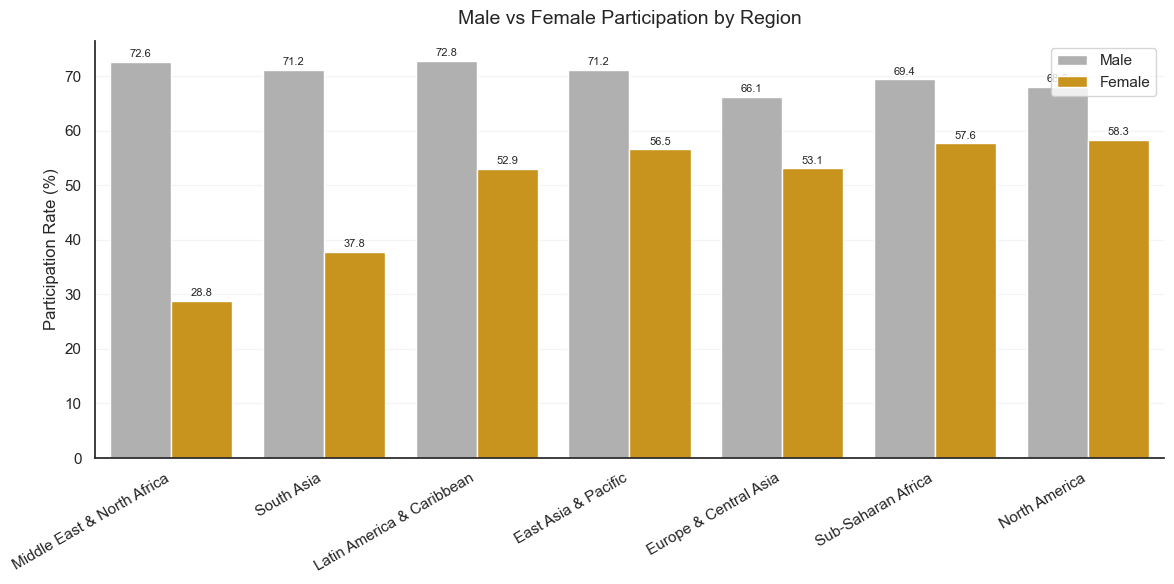

In [80]:
# Sắp xếp region theo Gap (Male - Female)
region_order = (
    df_latest.groupby("Region")
    .apply(lambda x: (x["Male"] - x["Female"]).mean())
    .sort_values(ascending=False)
    .index
)

region_mean = df_latest.groupby("Region")[["Male", "Female"]].mean().reset_index()

region_mean = region_mean.melt(
    id_vars="Region",
    value_vars=["Male", "Female"],
    var_name="Gender",
    value_name="Rate"
)

# Palette: Male xám, Female nổi bật
palette = {
    "Male": "#B0B0B0",
    "Female": "#E69F00"
}

# Vẽ biểu đồ
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=region_mean,
    x="Region",
    y="Rate",
    hue="Gender",
    order=region_order,
    palette=palette
)

# Làm sạch biểu đồ
plt.title("Male vs Female Participation by Region", fontsize=14, pad=12)
plt.xlabel("")
plt.ylabel("Participation Rate (%)")

# Grid nhẹ
ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.grid(False)

# Bỏ viền thừa
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Xoay label cho dễ đọc
plt.xticks(rotation=30, ha="right")

# Direct labeling (thay legend)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            height + 0.5,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# Đưa legend lên trên (hoặc có thể bỏ hẳn)
plt.legend(title="", loc="upper right")

plt.tight_layout()
plt.show()

**Nhận xét và insight từ biểu đồ**

**So sánh giữa Nam và Nữ**
- Ở tất cả các khu vực, tỷ lệ tham gia của **Nam** đều cao hơn **Nữ**  
- Điều này cho thấy khoảng cách giới vẫn tồn tại trên phạm vi toàn cầu  

---

**Khu vực có khoảng cách lớn**
- **Middle East & North Africa** có chênh lệch rất lớn giữa Nam `(~72%)` và Nữ `(~29%)`  
- **South Asia** cũng có khoảng cách đáng kể  

---

**Khu vực có khoảng cách nhỏ hơn**
- **North America** và **Sub-Saharan Africa** có mức chênh lệch thấp hơn  
- **East Asia & Pacific** và **Europe & Central Asia** có sự cân bằng tương đối hơn  

---

**Insight chính**

> Khoảng cách giới trong lực lượng lao động tồn tại ở tất cả các khu vực, nhưng mức độ khác biệt rất lớn, phản ánh sự khác nhau về điều kiện kinh tế, xã hội và văn hóa  

### **Bước 3: Kết luận chung**
**Thực trạng toàn cầu**
- **Ưu thế nam giới:** Ở tất cả các khu vực, tỷ lệ tham gia lực lượng lao động của **Nam giới luôn cao hơn Nữ giới**.
- **Sự phân hóa khu vực:** Khoảng cách này đặc biệt gay gắt tại **Middle East & North Africa** và **South Asia**, trong khi các khu vực như **North America** hay **Europe** có xu hướng cân bằng hơn.

---

**Insight chính**

> Khoảng cách giới không chỉ là con số thống kê mà là tấm gương phản chiếu **định kiến văn hóa và rào cản chính sách**. Thu hẹp khoảng cách này là chìa khóa để khai thác tối đa tiềm năng nguồn nhân lực toàn cầu.

## **Nhận xét tổng quát: Sự phát triển Con người và Xã hội**

**Sự cộng hưởng giữa Kinh tế, Sức khỏe và Đô thị hóa**
- **Quỹ đạo đi lên:** Tuổi thọ trung bình và tỷ lệ đô thị hóa toàn cầu có sự tương quan thuận và cùng tăng trưởng mạnh mẽ. Điều này cho thấy sự thịnh vượng về kinh tế (GDP) đã được chuyển hóa hiệu quả thành các điều kiện sống cơ bản.
- **Điểm bão hòa:** Tại các khu vực phát triển, cả tuổi thọ và đô thị hóa đều đã chạm ngưỡng bão hòa. Lúc này, chất lượng sống không còn phụ thuộc vào tốc độ tăng trưởng mà nằm ở tính **bền vững và chiều sâu**.

**Rào cản về Bình đẳng giới và Cấu trúc xã hội**
- **Khoảng cách giới dai dẳng:** Mặc dù kinh tế và y tế tiến bộ, khoảng cách tham gia lực lượng lao động giữa Nam và Nữ vẫn là một bài toán chưa có lời giải chung, đặc biệt tại các khu vực đang chuyển đổi nhanh.
- **Bất bình đẳng kép:** Các quốc gia thu nhập thấp không chỉ tụt hậu về chỉ số sinh học (tuổi thọ) và hạ tầng (đô thị), mà còn đối mặt với khoảng cách giới lớn, tạo thành vòng lặp kìm hãm phát triển.

**Sự phân cực và tính hội tụ toàn cầu**
- **Hai xu hướng trái ngược:** Trong khi khoảng cách về `đô thị hóa` đang dần thu hẹp nhờ sự bứt phá của các nước đang phát triển (xu hướng hội tụ), thì bất bình đẳng về **sức khỏe và tuổi thọ** giữa các nhóm thu nhập vẫn dai dẳng và chưa có dấu hiệu cải thiện rõ rệt (xu hướng phân kỳ)."

---

**Insight chính**

> Sự thịnh vượng của một quốc gia không chỉ được đo bằng con số GDP hay những tòa nhà cao tầng, mà là sự tổng hòa của ba yếu tố: **Sức khỏe dân cư (Tuổi thọ)**, **Sự hiện đại hóa (Đô thị)** và **Công bằng xã hội (Bình đẳng giới)**. Một nền phát triển thực sự bền vững là khi mọi giới tính và mọi tầng lớp thu nhập đều được hưởng lợi tương xứng từ tiến bộ chung của nhân loại.